In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import math
import os
import shutil
import glob
import sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, classification_report


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/sanilawijesekara/ricevision-v3-balanced/tensorflow2/balanced-v1/1/ricevision_v3_balanced_v1.keras
/kaggle/input/sl-paddy-combined/sl_district_paddy.csv


In [2]:
work_dir = "/kaggle/working"

for filename in os.listdir(work_dir):
    file_path = os.path.join(work_dir, filename)
    if os.path.isfile(file_path) or os.path.islink(file_path):
        os.unlink(file_path)
    elif os.path.isdir(file_path):
        shutil.rmtree(file_path)

print("Output directory cleaned!")

Output directory cleaned!


In [3]:
df = pd.read_csv("/kaggle/input/sl-paddy-combined/sl_district_paddy.csv")
df.head()

,Unnamed: 0.1,unnamed: 0,pixel_id,year,date,rain_1d_mean,rain_3d_mean,rain_7d_mean,rain_14d_mean,rain_30d_mean,...,average_yield,ds_division,hazard_drought,hazard_flood,hazard_heat,hazard_heavy_rain,hazard_landslide,hazard_lightning,hazard_wind,Unnamed: 0
0,0,0,0,2022,2022-01-07,0.0,0.000000,26.013073,26.013073,101.000926,...,2764.0,Weligama,False,False,False,False,False,False,False,NaN
1,1,4645,62,2022,2022-01-07,0.0,6.885350,27.541401,27.541401,112.383800,...,2764.0,Thihagoda,False,False,False,False,False,False,False,NaN
2,2,7671,102,2022,2022-01-07,0.0,7.544059,30.176235,30.176235,102.502235,...,2764.0,Welipitiya,False,False,False,False,False,False,False,NaN
3,3,4691,63,2022,2022-01-07,0.0,6.885350,27.541401,27.541401,112.383800,...,2764.0,Devinuwara,False,False,False,False,False,False,False,NaN
4,4,3670,48,2022,2022-01-07,0.0,5.812001,23.248005,23.248005,108.151281,...,2764.0,Thihagoda,False,False,False,False,False,False,False,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2578121 entries, 0 to 2578120
Data columns (total 66 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Unnamed: 0.1          int64  
 1   unnamed: 0            int64  
 2   pixel_id              int64  
 3   year                  int64  
 4   date                  object 
 5   rain_1d_mean          float64
 6   rain_3d_mean          float64
 7   rain_7d_mean          float64
 8   rain_14d_mean         float64
 9   rain_30d_mean         float64
 10  tmean_mean            float64
 11  tmax_mean             float64
 12  tmin_mean             float64
 13  t_day_mean            float64
 14  t_night_mean          float64
 15  rh_mean_mean          float64
 16  lat                   float64
 17  lon                   float64
 18  elevation             int64  
 19  slope                 float64
 20  ten_day_start         object 
 21  delta_days            float64
 22  doy                   int64  
 23  doy_sin

In [5]:
df.isnull().sum()

Unnamed: 0.1               0
unnamed: 0                 0
pixel_id                   0
year                       0
date                       0
                      ...   
hazard_heavy_rain          0
hazard_landslide           0
hazard_lightning           0
hazard_wind                0
Unnamed: 0           2232728
Length: 66, dtype: int64

In [6]:
df.describe(include="all")

,Unnamed: 0.1,unnamed: 0,pixel_id,year,date,rain_1d_mean,rain_3d_mean,rain_7d_mean,rain_14d_mean,rain_30d_mean,...,average_yield,ds_division,hazard_drought,hazard_flood,hazard_heat,hazard_heavy_rain,hazard_landslide,hazard_lightning,hazard_wind,Unnamed: 0
count,2.578121e+06,2.578121e+06,2.578121e+06,2.578121e+06,2578121,2.578121e+06,2.578121e+06,2.578121e+06,2.578121e+06,2.578121e+06,...,2.578121e+06,2578042,2578121,2578121,2578121,2578121,2578121,2578121,2578121,345393.000000
unique,NaN,NaN,NaN,NaN,438,NaN,NaN,NaN,NaN,NaN,...,NaN,293,2,2,1,2,2,2,2,NaN
top,NaN,NaN,NaN,NaN,2025-07-10,NaN,NaN,NaN,NaN,NaN,...,NaN,Dimbulagala,False,False,False,False,False,False,False,NaN
freq,NaN,NaN,NaN,NaN,24587,NaN,NaN,NaN,NaN,NaN,...,NaN,86781,2577017,2572807,2578121,2566795,2577648,2570368,2539035,NaN
mean,1.289060e+06,1.076895e+05,1.250469e+03,2.023562e+03,NaN,1.785611e+00,6.485225e+00,1.909840e+01,4.746426e+01,1.208426e+02,...,3.103503e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172696.000000
std,7.442396e+05,8.847607e+04,1.053511e+03,1.141287e+00,NaN,5.177568e+00,1.360156e+01,3.118202e+01,6.451451e+01,1.308639e+02,...,1.670438e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99706.515101
min,0.000000e+00,0.000000e+00,0.000000e+00,2.022000e+03,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,6.445300e+05,3.455800e+04,4.020000e+02,2.023000e+03,NaN,0.000000e+00,0.000000e+00,0.000000e+00,4.303105e+00,2.408202e+01,...,2.526000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86348.000000
50%,1.289060e+06,8.353300e+04,9.490000e+02,2.024000e+03,NaN,0.000000e+00,0.000000e+00,5.652090e+00,2.072660e+01,7.379781e+01,...,3.557000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,172696.000000
75%,1.933590e+06,1.666980e+05,1.900000e+03,2.025000e+03,NaN,0.000000e+00,6.929517e+00,2.455739e+01,6.685093e+01,1.751305e+02,...,4.302000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,259044.000000


# **Remove unnecessary columns**

In [7]:
df.drop(columns=['unnamed: 0','Unnamed: 0.1','Unnamed: 0', 'average_yield'], inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2578121 entries, 0 to 2578120
Data columns (total 62 columns):
 #   Column                Dtype  
---  ------                -----  
 0   pixel_id              int64  
 1   year                  int64  
 2   date                  object 
 3   rain_1d_mean          float64
 4   rain_3d_mean          float64
 5   rain_7d_mean          float64
 6   rain_14d_mean         float64
 7   rain_30d_mean         float64
 8   tmean_mean            float64
 9   tmax_mean             float64
 10  tmin_mean             float64
 11  t_day_mean            float64
 12  t_night_mean          float64
 13  rh_mean_mean          float64
 14  lat                   float64
 15  lon                   float64
 16  elevation             int64  
 17  slope                 float64
 18  ten_day_start         object 
 19  delta_days            float64
 20  doy                   int64  
 21  doy_sin               float64
 22  doy_cos               float64
 23  ndvi_me

# **EDA**

# **District**

In [9]:
df['district'].unique()

array(['Matara', 'Colombo', 'Hambantota', 'Gampaha', 'Matale', 'Mannar',
       'Nuwara Eliya', 'Kilinochchi', 'Galle', 'Batticaloa', 'Kurunegala',
       'Badulla', 'Ratnapura', 'Vavuniya', 'Trincomalee', 'Kaluthara',
       'Kandy', 'Jaffna', 'Mullaitivu', 'Monaragala', 'Ampara',
       'Puttalam', 'Anuradhapura', 'Kegalle', 'Polonnaruwa'], dtype=object)

In [10]:
df['district'].value_counts()

district
Anuradhapura    345393
Polonnaruwa     328983
Batticaloa      299045
Ampara          286896
Trincomalee     217704
Kurunegala      162658
Monaragala      127657
Hambantota      117715
Kilinochchi     114916
Mullaitivu      105242
Mannar          101717
Vavuniya         72819
Puttalam         65122
Matale           55529
Jaffna           50579
Badulla          22476
Matara           21286
Kandy            19254
Gampaha          19015
Ratnapura        18311
Kaluthara         9576
Galle             6103
Kegalle           4673
Colombo           3698
Nuwara Eliya      1754
Name: count, dtype: int64

<Axes: xlabel='district'>

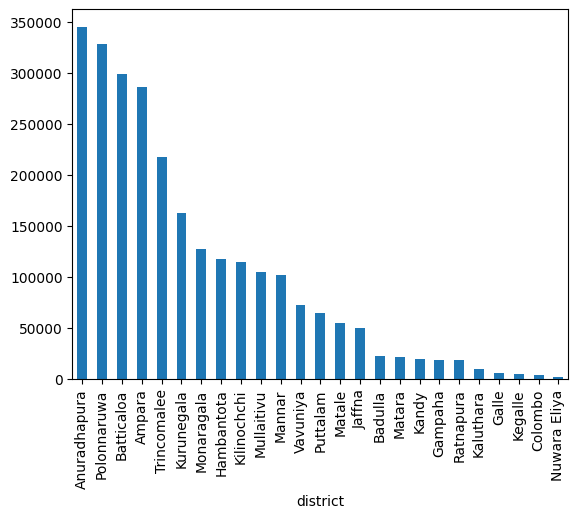

In [11]:
df['district'].value_counts().plot(kind='bar')

# **DS Division**

In [12]:
df['ds_division'].unique()

array(['Weligama', 'Thihagoda', 'Welipitiya', 'Devinuwara', 'Malimbada',
       'Kaburupitiya', 'Kirinda Puhulwella', 'Pasgoda', 'Pitabaddara',
       'Matara Four Gravets', 'Kotapola', 'Akuressa', 'Athuraliya',
       'Dikwella', 'Hakmana', 'Mulatiyana', 'Walasmulla', 'Horana',
       'Kesbewa', 'Seethawaka', 'Kaduwela', 'Ratmalana', 'Padukka',
       'Moratuwa', 'Maharagama', 'Homagama', 'Sri Jayawardanapura Kotte',
       'Hambantota', 'Sooriyawewa', 'Lunugamwehera', 'Thissamaharama',
       'Angunakolapelessa', 'Ambalantota', 'Katuwana', 'Weeraketiya',
       'Embilipitiya', 'Tangalle', 'Beliatta', 'Sevanagala', 'Okewela',
       'Dompe', 'Attanagalla', 'Gampaha', 'Ja Ela', 'Mahara', 'Katana',
       'Minuwangoda', 'Mirigama', 'Divulapitiya', 'Biyagama', 'Wattala',
       'Ukuwela', 'Dambulla', 'Wilgamuwa', 'Naula', 'Laggala',
       'Ambanganga', 'Matale', 'Galewela', 'Pallepola', 'Yatawatta',
       'Palagala', 'Manthai West', 'Nanaddan', 'Madhu', 'Mannar Town',
       'Musali', 

In [13]:
len(df['ds_division'].unique())

294

In [14]:
df['stage'].unique()

array([4, 0, 1, 2, 3])

<Axes: >

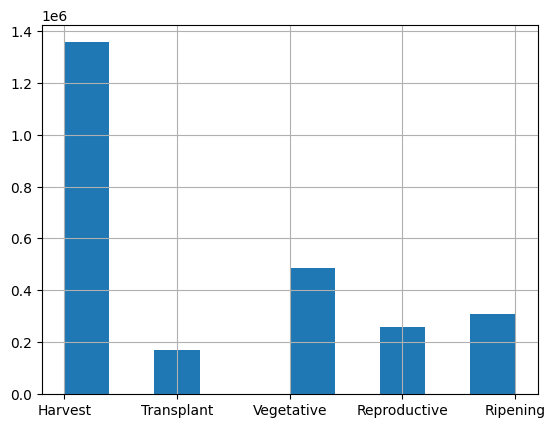

In [15]:
df['stage_name'].hist()

<Axes: >

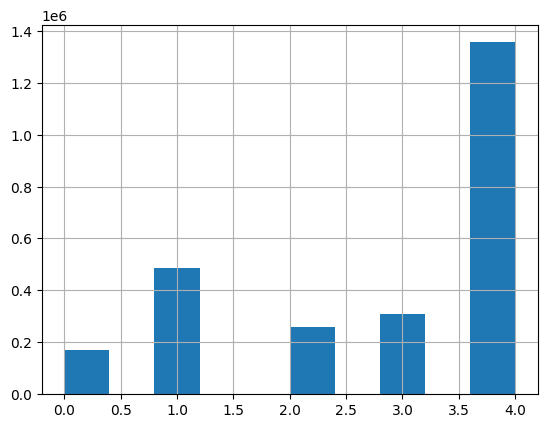

In [16]:
df['stage'].hist()

# **Making district id**

In [17]:
from sklearn.preprocessing import LabelEncoder

# 1. Initialize LabelEncoder
le = LabelEncoder()

# 2. Create district_id (0-24)
# We fit on train and transform both to maintain consistency
df['district_id'] = le.fit_transform(df['district'])

# Store the mapping to verify later
district_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"✅ Encoded {len(district_mapping)} districts.")

✅ Encoded 25 districts.


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2578121 entries, 0 to 2578120
Data columns (total 63 columns):
 #   Column                Dtype  
---  ------                -----  
 0   pixel_id              int64  
 1   year                  int64  
 2   date                  object 
 3   rain_1d_mean          float64
 4   rain_3d_mean          float64
 5   rain_7d_mean          float64
 6   rain_14d_mean         float64
 7   rain_30d_mean         float64
 8   tmean_mean            float64
 9   tmax_mean             float64
 10  tmin_mean             float64
 11  t_day_mean            float64
 12  t_night_mean          float64
 13  rh_mean_mean          float64
 14  lat                   float64
 15  lon                   float64
 16  elevation             int64  
 17  slope                 float64
 18  ten_day_start         object 
 19  delta_days            float64
 20  doy                   int64  
 21  doy_sin               float64
 22  doy_cos               float64
 23  ndvi_me

In [19]:
df['district_id'].unique()

array([16,  4,  7,  6, 15, 14, 19, 12,  5,  3, 13,  2, 22, 24, 23,  9, 10,
        8, 18, 17,  0, 21,  1, 11, 20])

# **Disaster Hazard Vectorization**

In [20]:
# Identify the boolean hazard columns
hazard_cols = [
    'hazard_drought', 'hazard_flood', 'hazard_heavy_rain',
    'hazard_landslide', 'hazard_lightning', 'hazard_wind'
]

# Convert Booleans to Integers (True/False -> 1/0) for the Sigmoid head
df[hazard_cols] = df[hazard_cols].astype(int)

In [21]:
df[hazard_cols].head()

,hazard_drought,hazard_flood,hazard_heavy_rain,hazard_landslide,hazard_lightning,hazard_wind
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


--- Hazard Frequency (Counts & Percentage) ---
                   Count  Percentage
hazard_wind        39086        1.52
hazard_heavy_rain  11326        0.44
hazard_lightning    7753        0.30
hazard_flood        5314        0.21
hazard_drought      1104        0.04
hazard_landslide     473        0.02


/tmp/ipykernel_55/2362891682.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hazard_summary['Count'], y=hazard_summary.index, palette='viridis')


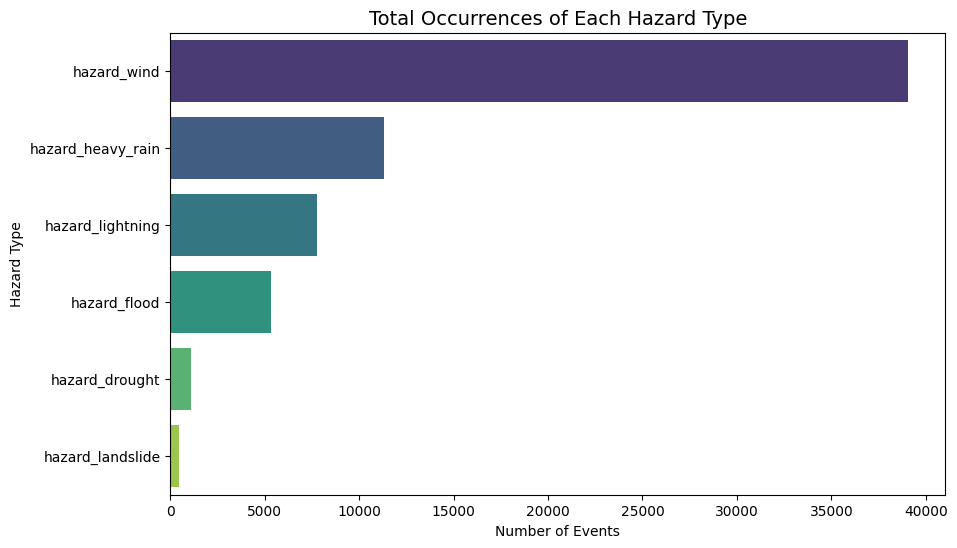

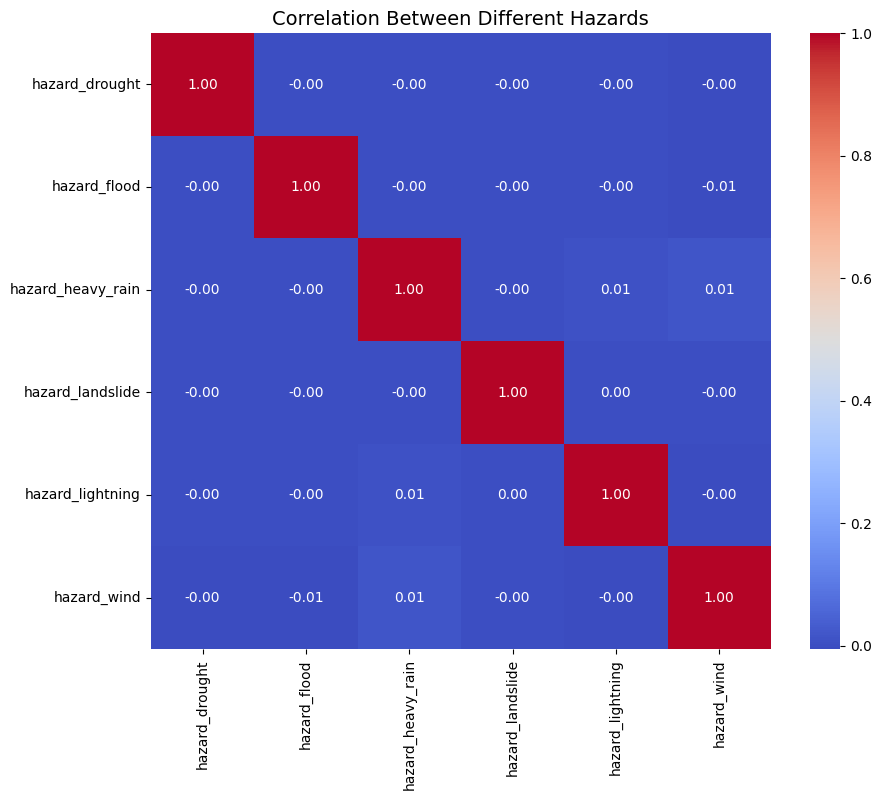

/tmp/ipykernel_55/2362891682.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=multi_hazard_counts.index, y=multi_hazard_counts.values, palette='magma')


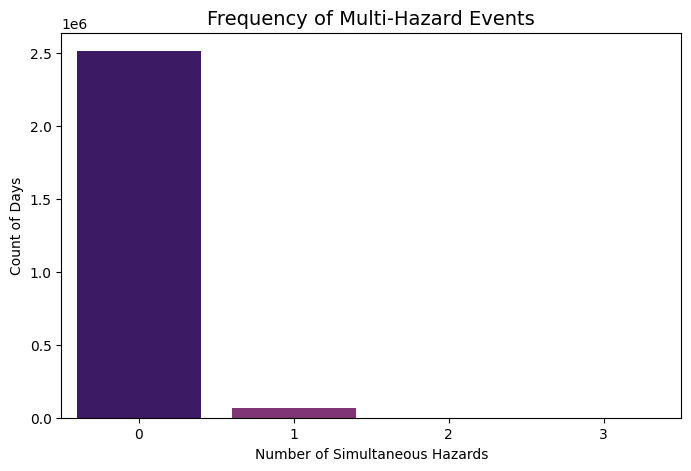

In [22]:
# 1. Basic Summary Stats
print("--- Hazard Frequency (Counts & Percentage) ---")
hazard_summary = pd.DataFrame({
    'Count': df[hazard_cols].sum(),
    'Percentage': (df[hazard_cols].mean() * 100).round(2)
}).sort_values('Count', ascending=False)
print(hazard_summary)

# 2. Visualization: Total Counts of Each Hazard
plt.figure(figsize=(10, 6))
sns.barplot(x=hazard_summary['Count'], y=hazard_summary.index, palette='viridis')
plt.title('Total Occurrences of Each Hazard Type', fontsize=14)
plt.xlabel('Number of Events')
plt.ylabel('Hazard Type')
plt.show()

# 3. Visualization: Correlation Heatmap
# (Do floods and heavy rain happen together? This chart will tell you.)
plt.figure(figsize=(10, 8))
sns.heatmap(df[hazard_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Different Hazards', fontsize=14)
plt.show()

# 4. Check for Multi-Hazard Events
# (How many days had more than one disaster at the same time?)
df['hazard_count'] = df[hazard_cols].sum(axis=1)
multi_hazard_counts = df['hazard_count'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=multi_hazard_counts.index, y=multi_hazard_counts.values, palette='magma')
plt.title('Frequency of Multi-Hazard Events', fontsize=14)
plt.xlabel('Number of Simultaneous Hazards')
plt.ylabel('Count of Days')
plt.show()

In [23]:
df.drop(columns=['hazard_heat'],inplace=True)

/tmp/ipykernel_55/3539874870.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/3539874870.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/3539874870.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/3539874870.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/3539874870.py:23: FutureWarning: 

Passing `pa

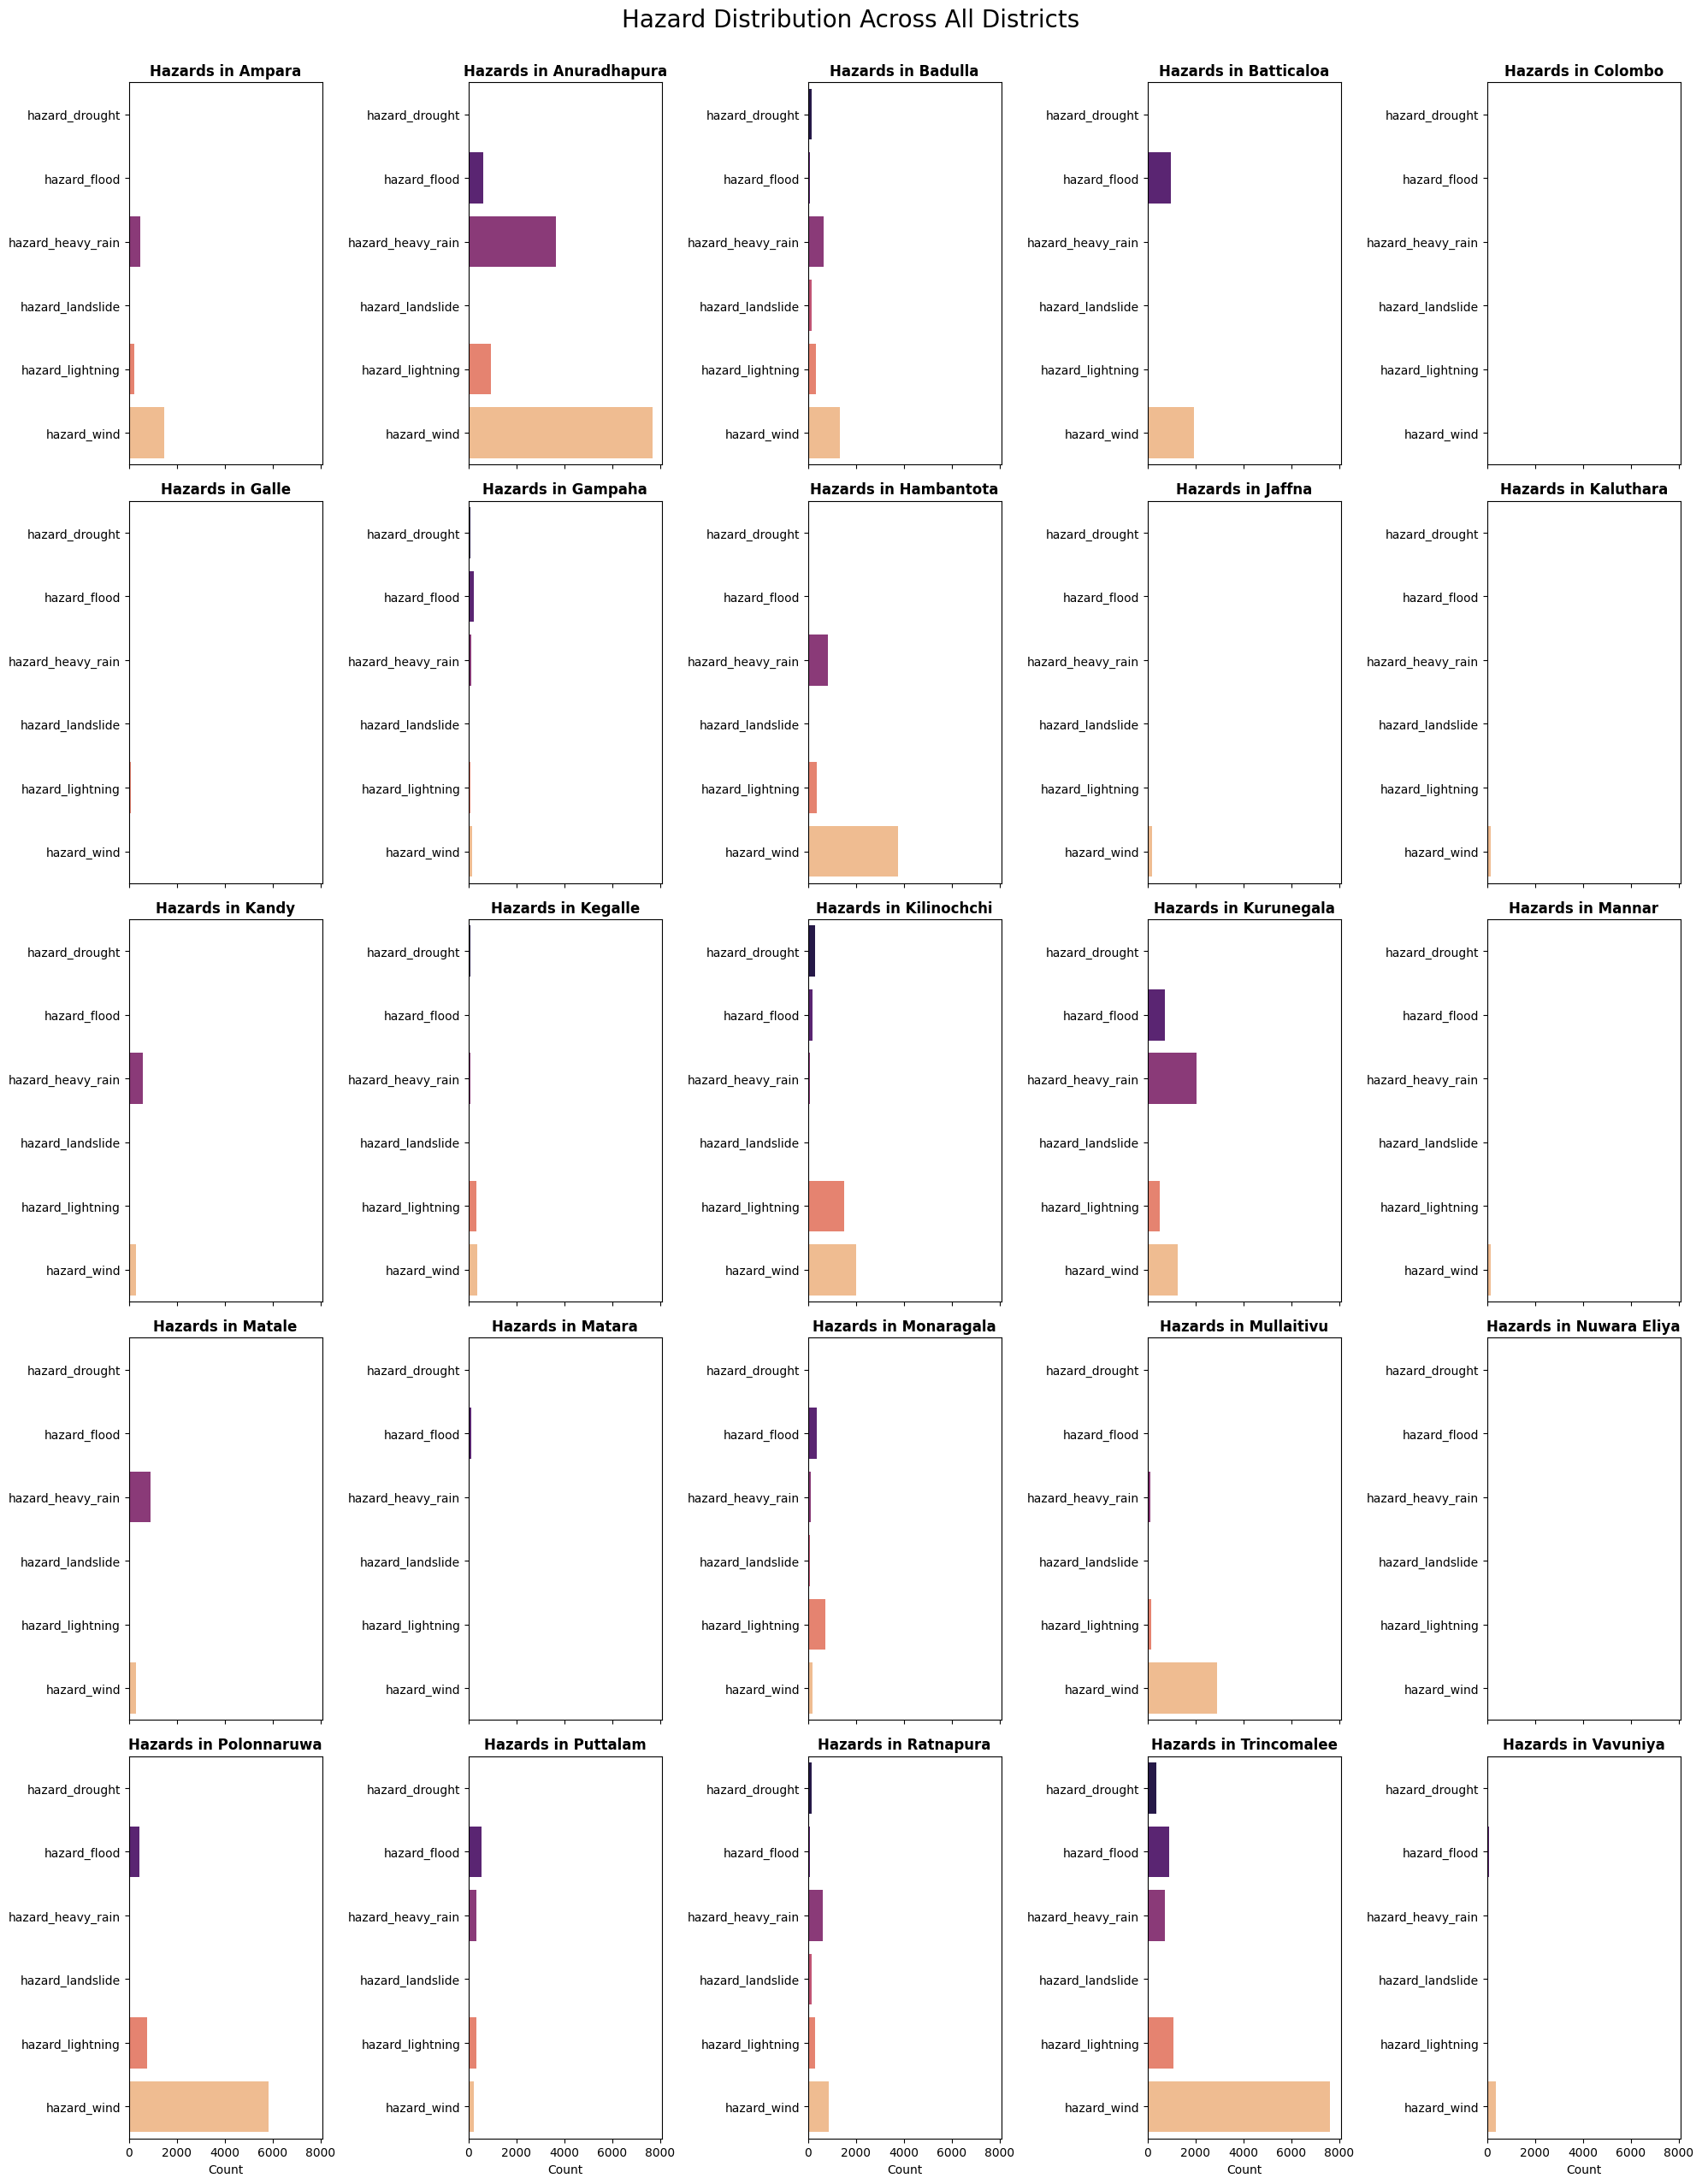

In [24]:
# 1. Identify unique districts
# Adjust 'district' to 'district_name' if your column name is different
districts = sorted(df['district'].unique())
n_districts = len(districts)

# 2. Define the grid (e.g., 5 columns for 25 districts)
cols = 5
rows = math.ceil(n_districts / cols)

# 3. Create the figure
fig, axes = plt.subplots(rows, cols, figsize=(20, 25), sharex=True)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# 4. Iterate through each district and plot
for i, district in enumerate(districts):
    # Filter data for the specific district
    district_df = df[df['district'] == district]
    
    # Calculate sums for each hazard
    hazard_totals = district_df[hazard_cols].sum()
    
    # Create the bar plot in the specific subplot
    sns.barplot(
        x=hazard_totals.values, 
        y=hazard_totals.index, 
        ax=axes[i], 
        palette='magma'
    )
    
    # Formatting each subplot
    axes[i].set_title(f"Hazards in {district}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("") # Remove y-label to save space
    
# 5. Hide any empty subplots (if districts < rows*cols)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# 6. Final Layout Adjustments
plt.tight_layout()
plt.suptitle('Hazard Distribution Across All Districts', fontsize=20, y=1.02)
plt.show()

# **District name to district ids**

In [25]:
# --- STEP 3: Categorical Encoding ---
# Convert District names (Objects) into Numerical IDs for the static input
le_district = LabelEncoder()
df['district_id'] = le_district.fit_transform(df['district'])

In [26]:
df['district_id'].head()

0    16
1    16
2    16
3    16
4    16
Name: district_id, dtype: int64

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2578121 entries, 0 to 2578120
Data columns (total 63 columns):
 #   Column                Dtype  
---  ------                -----  
 0   pixel_id              int64  
 1   year                  int64  
 2   date                  object 
 3   rain_1d_mean          float64
 4   rain_3d_mean          float64
 5   rain_7d_mean          float64
 6   rain_14d_mean         float64
 7   rain_30d_mean         float64
 8   tmean_mean            float64
 9   tmax_mean             float64
 10  tmin_mean             float64
 11  t_day_mean            float64
 12  t_night_mean          float64
 13  rh_mean_mean          float64
 14  lat                   float64
 15  lon                   float64
 16  elevation             int64  
 17  slope                 float64
 18  ten_day_start         object 
 19  delta_days            float64
 20  doy                   int64  
 21  doy_sin               float64
 22  doy_cos               float64
 23  ndvi_me

# **Pest flag**

<Axes: >

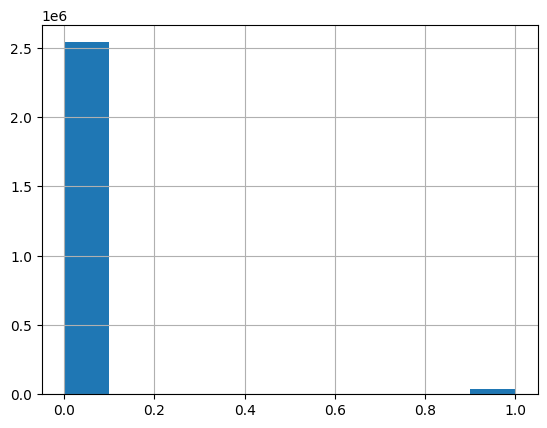

In [28]:
df['pest_flag'].hist()

# **Feature Extraction for LSTM**

In [29]:
# --- A. Define Dynamic Time-Series Features (X1) ---
ts_features = [
    'ndvi_median_smooth', 'lswi_median_smooth', 'evi_median_smooth', 
    'ndwi_median_smooth', 'bsi_median_smooth', 'ndvi_vel_z', 'lswi_vel_z', 
    'rain_7d_mean', 'rain_14d_mean', 'tmean_mean','bsi_z', 
    'rh_mean_mean', 'delta_days', 'doy_sin', 'doy_cos'
]

# --- B. Define Static Geospatial Features (X2) ---
static_features = ['lat', 'lon', 'elevation', 'slope', 'district_id']

# --- C. Define Multi-Head Targets (Y) ---
# Head 5 is a vector of all hazard columns
hazard_cols = [
    'hazard_drought', 'hazard_flood', 'hazard_heavy_rain', 
    'hazard_landslide', 'hazard_lightning', 'hazard_wind'
]

target_cols = ['stage', 'ndvi_zscore', 'cpi'] + hazard_cols

# 1. Combine all required column names into a single list
# We include pixel_id and date for sequencing later
all_required_cols = (
    ['pixel_id', 'date','year','stage_name','month','season'] + 
    ts_features + 
    static_features + 
    target_cols
)

# 2. Extract only these columns from the main dataframe
# This effectively drops the other ~40 unnecessary columns
df_lstm = df[all_required_cols].copy()

# 3. Optimize Data Types (Crucial for 1.2GB+ datasets)
# Convert Floats to 32-bit to save memory
float_cols = df_lstm.select_dtypes(include=['float64']).columns
df_lstm[float_cols] = df_lstm[float_cols].astype('float32')

# Convert Hazards and Stage to 32-bit Integers
int_cols = ['stage', 'pixel_id', 'district_id'] + hazard_cols
df_lstm[int_cols] = df_lstm[int_cols].astype('int32')

print(f"Extraction complete. New Shape: {df_lstm.shape}")
print(f"Memory Usage Reduced to: {df_lstm.memory_usage().sum() / 1024**2:.2f} MB")

# Optional: Ensure the final extracted df is perfectly typed
df_lstm['stage'] = df_lstm['stage'].astype('int32')
df_lstm['ndvi_zscore'] = df_lstm['ndvi_zscore'].astype('float32')
df_lstm['cpi'] = df_lstm['cpi'].astype('float32')
df_lstm.head()

Extraction complete. New Shape: (2578121, 35)
Memory Usage Reduced to: 403.22 MB


,pixel_id,date,year,stage_name,month,season,ndvi_median_smooth,lswi_median_smooth,evi_median_smooth,ndwi_median_smooth,...,district_id,stage,ndvi_zscore,cpi,hazard_drought,hazard_flood,hazard_heavy_rain,hazard_landslide,hazard_lightning,hazard_wind
0,0,2022-01-07,2022,Harvest,1,Maha,0.712585,0.223793,0.461426,0.092353,...,16,4,-0.360078,0.0,0,0,0,0,0,0
1,62,2022-01-07,2022,Harvest,1,Maha,0.865018,0.385506,0.545277,-0.031396,...,16,4,1.363526,0.0,0,0,0,0,0,0
2,102,2022-01-07,2022,Harvest,1,Maha,0.475954,0.266371,0.255453,0.165480,...,16,4,-3.035747,0.0,0,0,0,0,0,0
3,63,2022-01-07,2022,Harvest,1,Maha,0.705414,0.297780,0.531722,-0.032800,...,16,4,-0.441161,0.0,0,0,0,0,0,0
4,48,2022-01-07,2022,Harvest,1,Maha,0.846465,0.359377,0.557315,-0.002840,...,16,4,1.153743,0.0,0,0,0,0,0,0


In [30]:
df_lstm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2578121 entries, 0 to 2578120
Data columns (total 35 columns):
 #   Column              Dtype  
---  ------              -----  
 0   pixel_id            int32  
 1   date                object 
 2   year                int64  
 3   stage_name          object 
 4   month               int64  
 5   season              object 
 6   ndvi_median_smooth  float32
 7   lswi_median_smooth  float32
 8   evi_median_smooth   float32
 9   ndwi_median_smooth  float32
 10  bsi_median_smooth   float32
 11  ndvi_vel_z          float32
 12  lswi_vel_z          float32
 13  rain_7d_mean        float32
 14  rain_14d_mean       float32
 15  tmean_mean          float32
 16  bsi_z               float32
 17  rh_mean_mean        float32
 18  delta_days          float32
 19  doy_sin             float32
 20  doy_cos             float32
 21  lat                 float32
 22  lon                 float32
 23  elevation           int64  
 24  slope               floa

In [31]:
len(df_lstm['pixel_id'].unique())

4721

# **Feature Distributions**

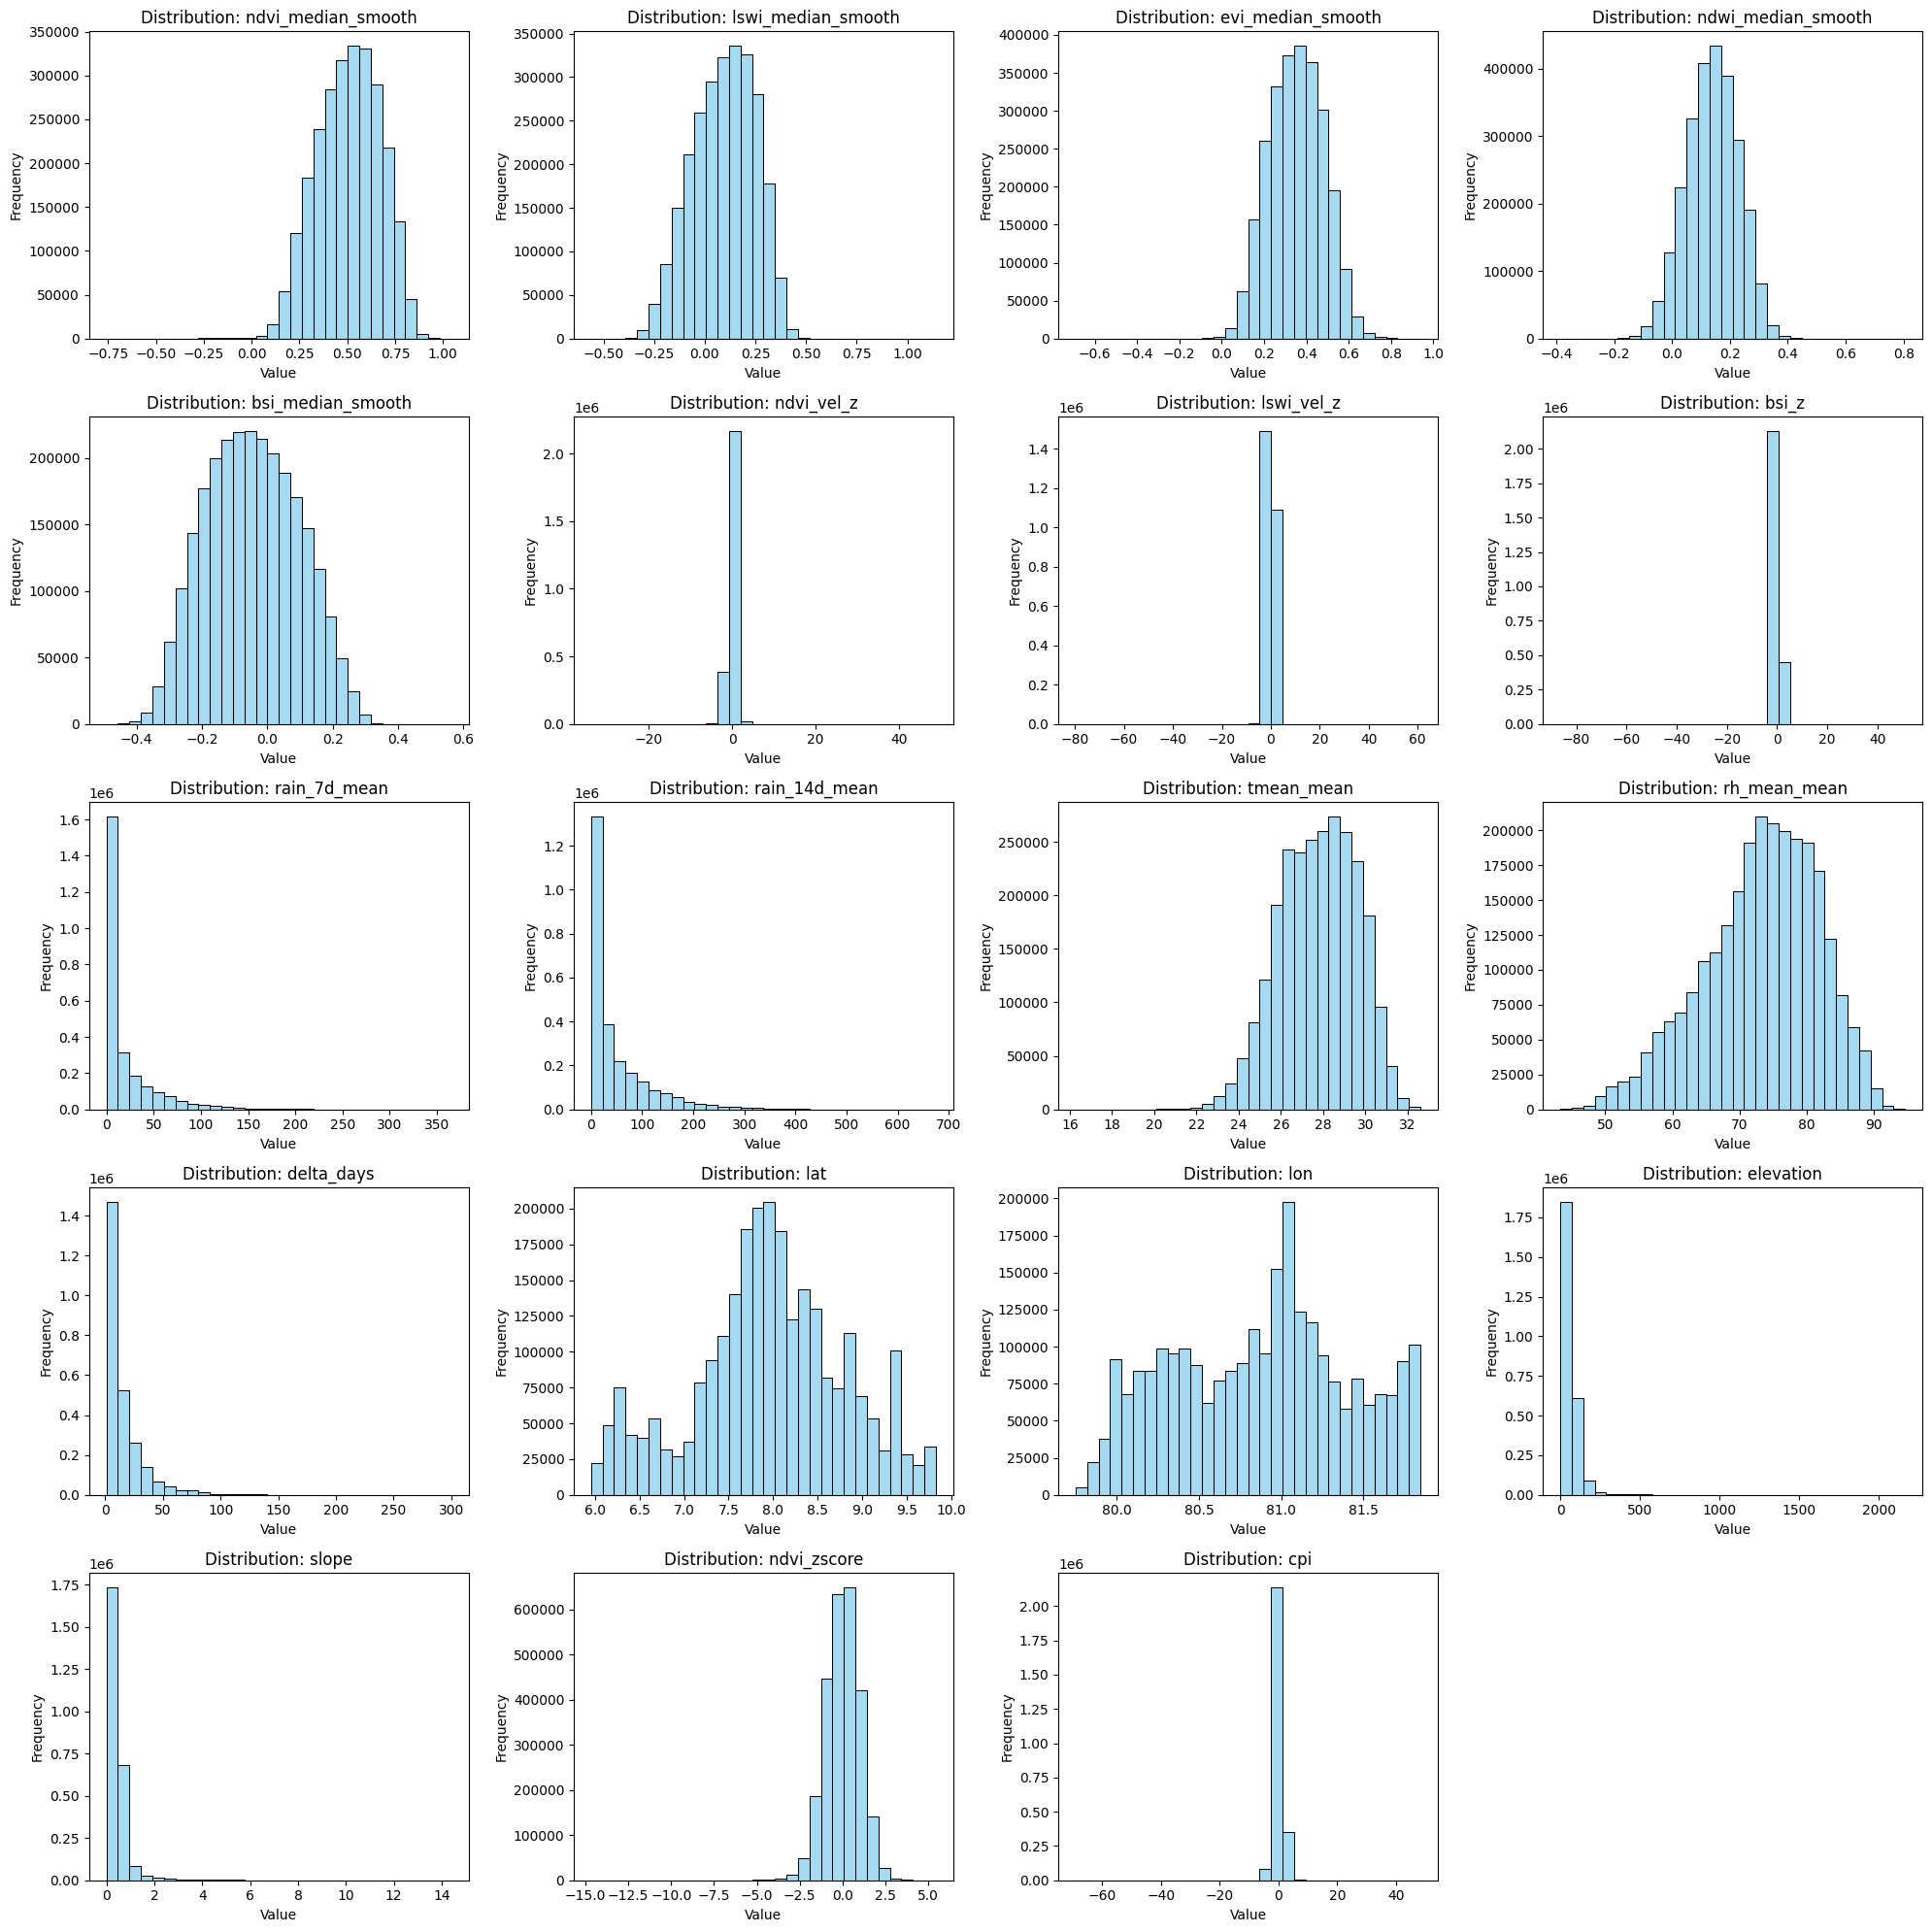

In [32]:
# Define columns to plot (excluding IDs and dates)
cols_to_plot = [
    'ndvi_median_smooth', 'lswi_median_smooth', 'evi_median_smooth', 
    'ndwi_median_smooth', 'bsi_median_smooth', 'ndvi_vel_z', 'lswi_vel_z','bsi_z', 
    'rain_7d_mean', 'rain_14d_mean', 'tmean_mean', 'rh_mean_mean', 
    'delta_days', 'lat', 'lon', 'elevation', 'slope', 'ndvi_zscore', 
    'cpi'
]

# Set up the grid
n_cols = 4
n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols
plt.figure(figsize=(20, n_rows * 4))

for i, col in enumerate(cols_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Filter out -1 for yield to see actual distribution
    data_to_plot = df_lstm[df_lstm[col] != -1][col] if col == 'average_yield' else df[col]
    
    sns.histplot(data_to_plot, bins=30, kde=False, color='skyblue')
    plt.title(f'Distribution: {col}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig("distributions.png")

# **Boxplots**

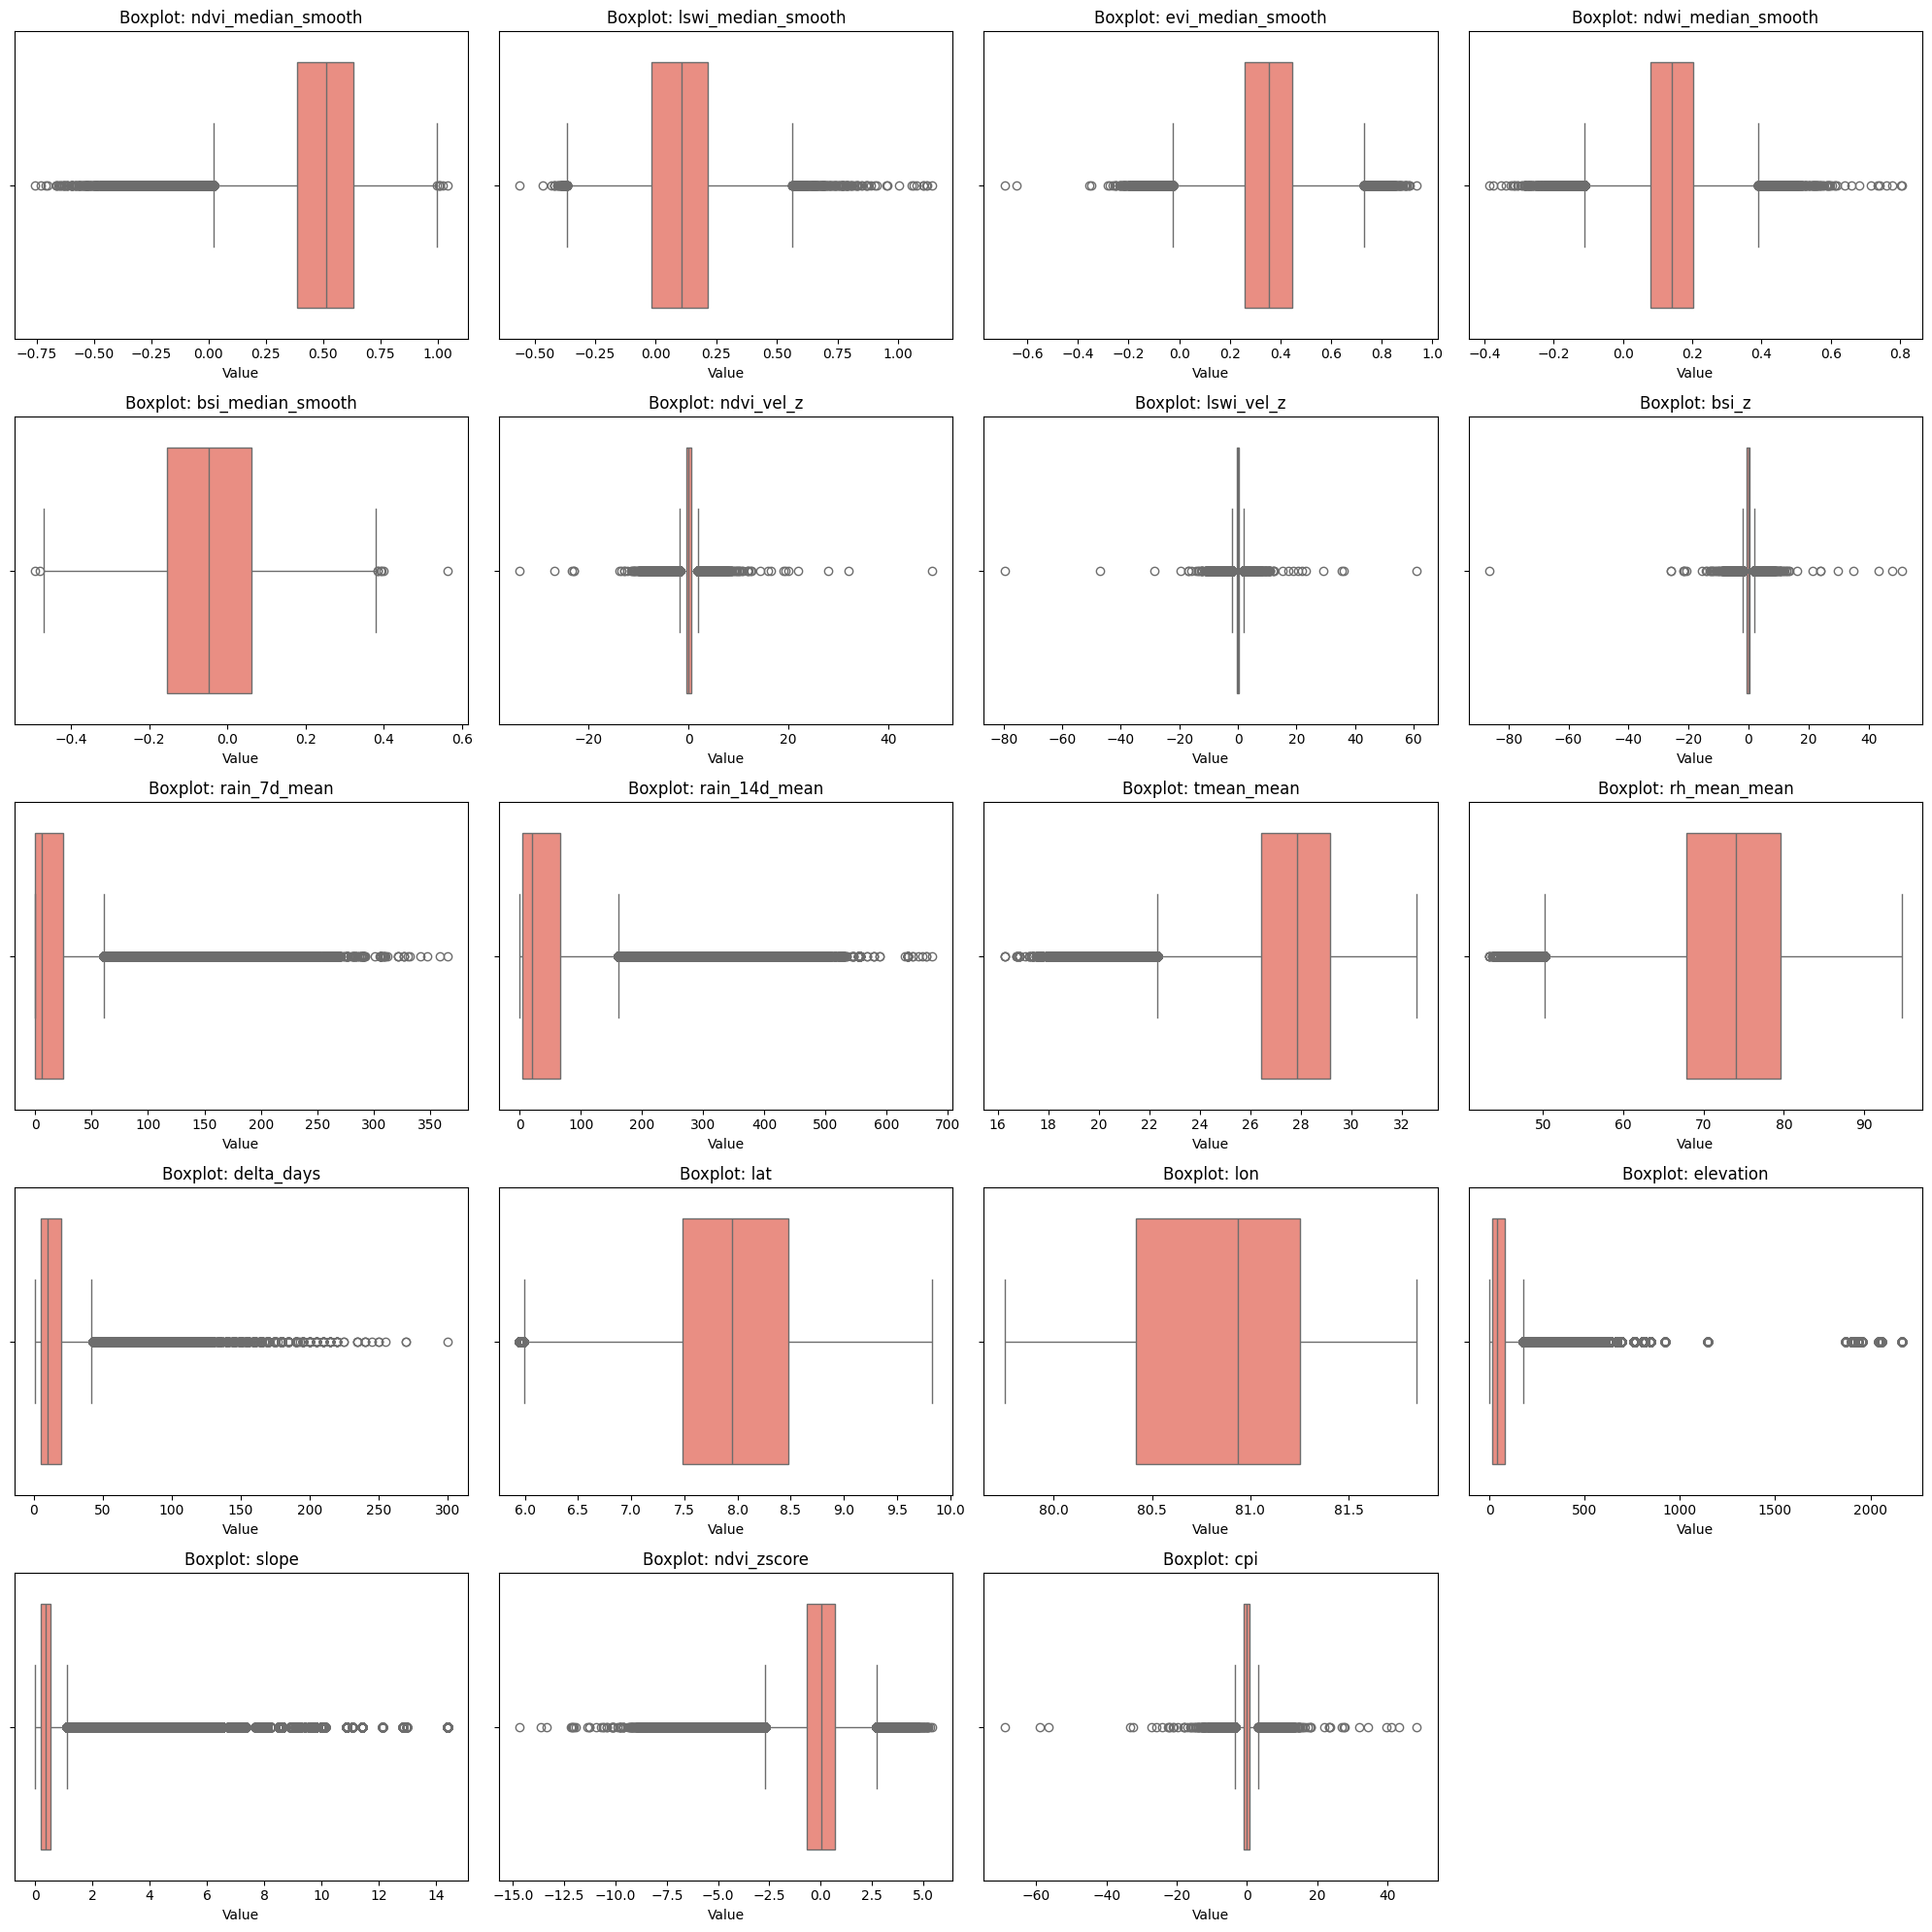

In [33]:
plt.figure(figsize=(20, n_rows * 4))

for i, col in enumerate(cols_to_plot):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Filter out missing yield for better scale
    data_to_plot = df_lstm[df_lstm[col] != -1][col] if col == 'average_yield' else df_lstm[col]
    
    sns.boxplot(x=data_to_plot, color='salmon')
    plt.title(f'Boxplot: {col}')
    plt.xlabel('Value')

plt.tight_layout()
plt.savefig("boxplots.png")

# **Define feature groups**

In [34]:
# --- 1. DEFINE GROUPS ---

# A. Already Scaled (Stage-Aware)
custom_scaled = ['ndvi_vel_z', 'lswi_vel_z', 'bsi_z', 'ndvi_zscore', 'cpi']

# B. Raw Temporal Features (Need Scaling + Go to LSTM)
raw_temporal = [
    'ndvi_median_smooth', 'lswi_median_smooth', 'evi_median_smooth', 
    'ndwi_median_smooth', 'bsi_median_smooth',
    'rain_7d_mean', 'rain_14d_mean', 'tmean_mean', 'rh_mean_mean', 
    'delta_days'
]

# C. Raw Static Features (Need Scaling + Go to Dense Layer)
raw_static = ['elevation', 'slope','lat','lon']

# D. Passthrough (No Scaling)
passthrough = ['doy_sin', 'doy_cos']

# --- 2. DEFINE INPUT LISTS (The Fix) ---

# LSTM Inputs (Only Time-Series)
TS_FEATURES = custom_scaled + raw_temporal + passthrough 
# This list now correctly EXCLUDES lat/lon/elevation/slope

# Scaling List (Both Temporal and Static)
features_to_scale = raw_temporal + raw_static

# **Train test split**

In [35]:
import numpy as np
import pandas as pd

# Ensure proper types
df_lstm['date'] = pd.to_datetime(df_lstm['date'])

# Pre-convert year to string once (Massive speedup for concatenation)
year_str = df_lstm['year'].astype(str)
next_year_str = (df_lstm['year'] + 1).astype(str)
prev_year_str = (df_lstm['year'] - 1).astype(str)
months = df_lstm['month'].values  # Extract as numpy array

# --- 1. VECTORIZED LOGIC (No Loops) ---

# Define conditions (Boolean Masks)
# Yala: May (5) to August (8)
cond_yala = (months >= 5) & (months <= 8)

# Maha Part 2: Jan (1) to March (3) -> Belongs to Previous Year's Maha
cond_maha_part2 = (months <= 3)

# Maha Part 1: Sep (9) to Dec (12) + April (4) -> Belongs to Current Year's Maha
# Note: Any month NOT in Yala is now Maha.
cond_maha_part1 = ~cond_yala & ~cond_maha_part2

# --- A. Create 'season' column ---
# If Yala, "Yala". Else, "Maha".
df_lstm['season'] = np.where(cond_yala, 'Yala', 'Maha')

# --- B. Create 'cycle_id' column ---
# We build the strings for all 3 possibilities at once
# 1. Yala: "2023_Yala"
cycle_yala = year_str + '_Yala'

# 2. Maha Part 2 (Jan-Mar): "2022_2023_Maha" (Year-1 to Year)
cycle_maha_p2 = prev_year_str + '_' + year_str + '_Maha'

# 3. Maha Part 1 (Sep-Dec + Apr): "2023_2024_Maha" (Year to Year+1)
cycle_maha_p1 = year_str + '_' + next_year_str + '_Maha'

# Apply logic using np.select
conditions = [cond_yala, cond_maha_part2, cond_maha_part1]
choices = [cycle_yala, cycle_maha_p2, cycle_maha_p1]

# default is just a fallback, logic covers all months
df_lstm['cycle_id'] = np.select(conditions, choices, default=cycle_maha_p1)

print("✅ Cycle IDs assigned (Vectorized).")

# --- 2. THE SPLIT: TRAIN (Past) vs TEST (2024 Yala + Future) ---
split_date = pd.Timestamp("2024-05-01") # Start of Yala 2024

# Boolean indexing
mask_train = df_lstm['date'] < split_date
mask_test = df_lstm['date'] >= split_date

train_df = df_lstm[mask_train].copy()
test_df = df_lstm[mask_test].copy()

print(f"✅ Training: Data before {split_date.date()}")
print(f"✅ Testing: Everything from {split_date.date()} onwards")
print(f"📊 Test Data unique cycles: {test_df['cycle_id'].unique()}")

# --- 3. ENCODE SEASONS ---
# Only 2 classes now: Maha=0, Yala=1
season_map = {'Maha': 0, 'Yala': 1}

train_df['season_id'] = train_df['season'].map(season_map).astype('int32')
test_df['season_id'] = test_df['season'].map(season_map).astype('int32')

print("✅ Season Encoding Complete.")

✅ Cycle IDs assigned (Vectorized).
✅ Training: Data before 2024-05-01
✅ Testing: Everything from 2024-05-01 onwards
📊 Test Data unique cycles: ['2024_Yala' '2024_2025_Maha' '2025_2026_Maha' '2025_Yala']
✅ Season Encoding Complete.


In [36]:
train_df.shape

(1503625, 37)

In [37]:
test_df.shape

(1074496, 37)

# **Feature Scaling**

In [38]:
# Scale everything (Temporal + Static) using 2022-2024 stats
scaler = StandardScaler()
train_df[features_to_scale] = scaler.fit_transform(train_df[features_to_scale])
test_df[features_to_scale] = scaler.transform(test_df[features_to_scale])

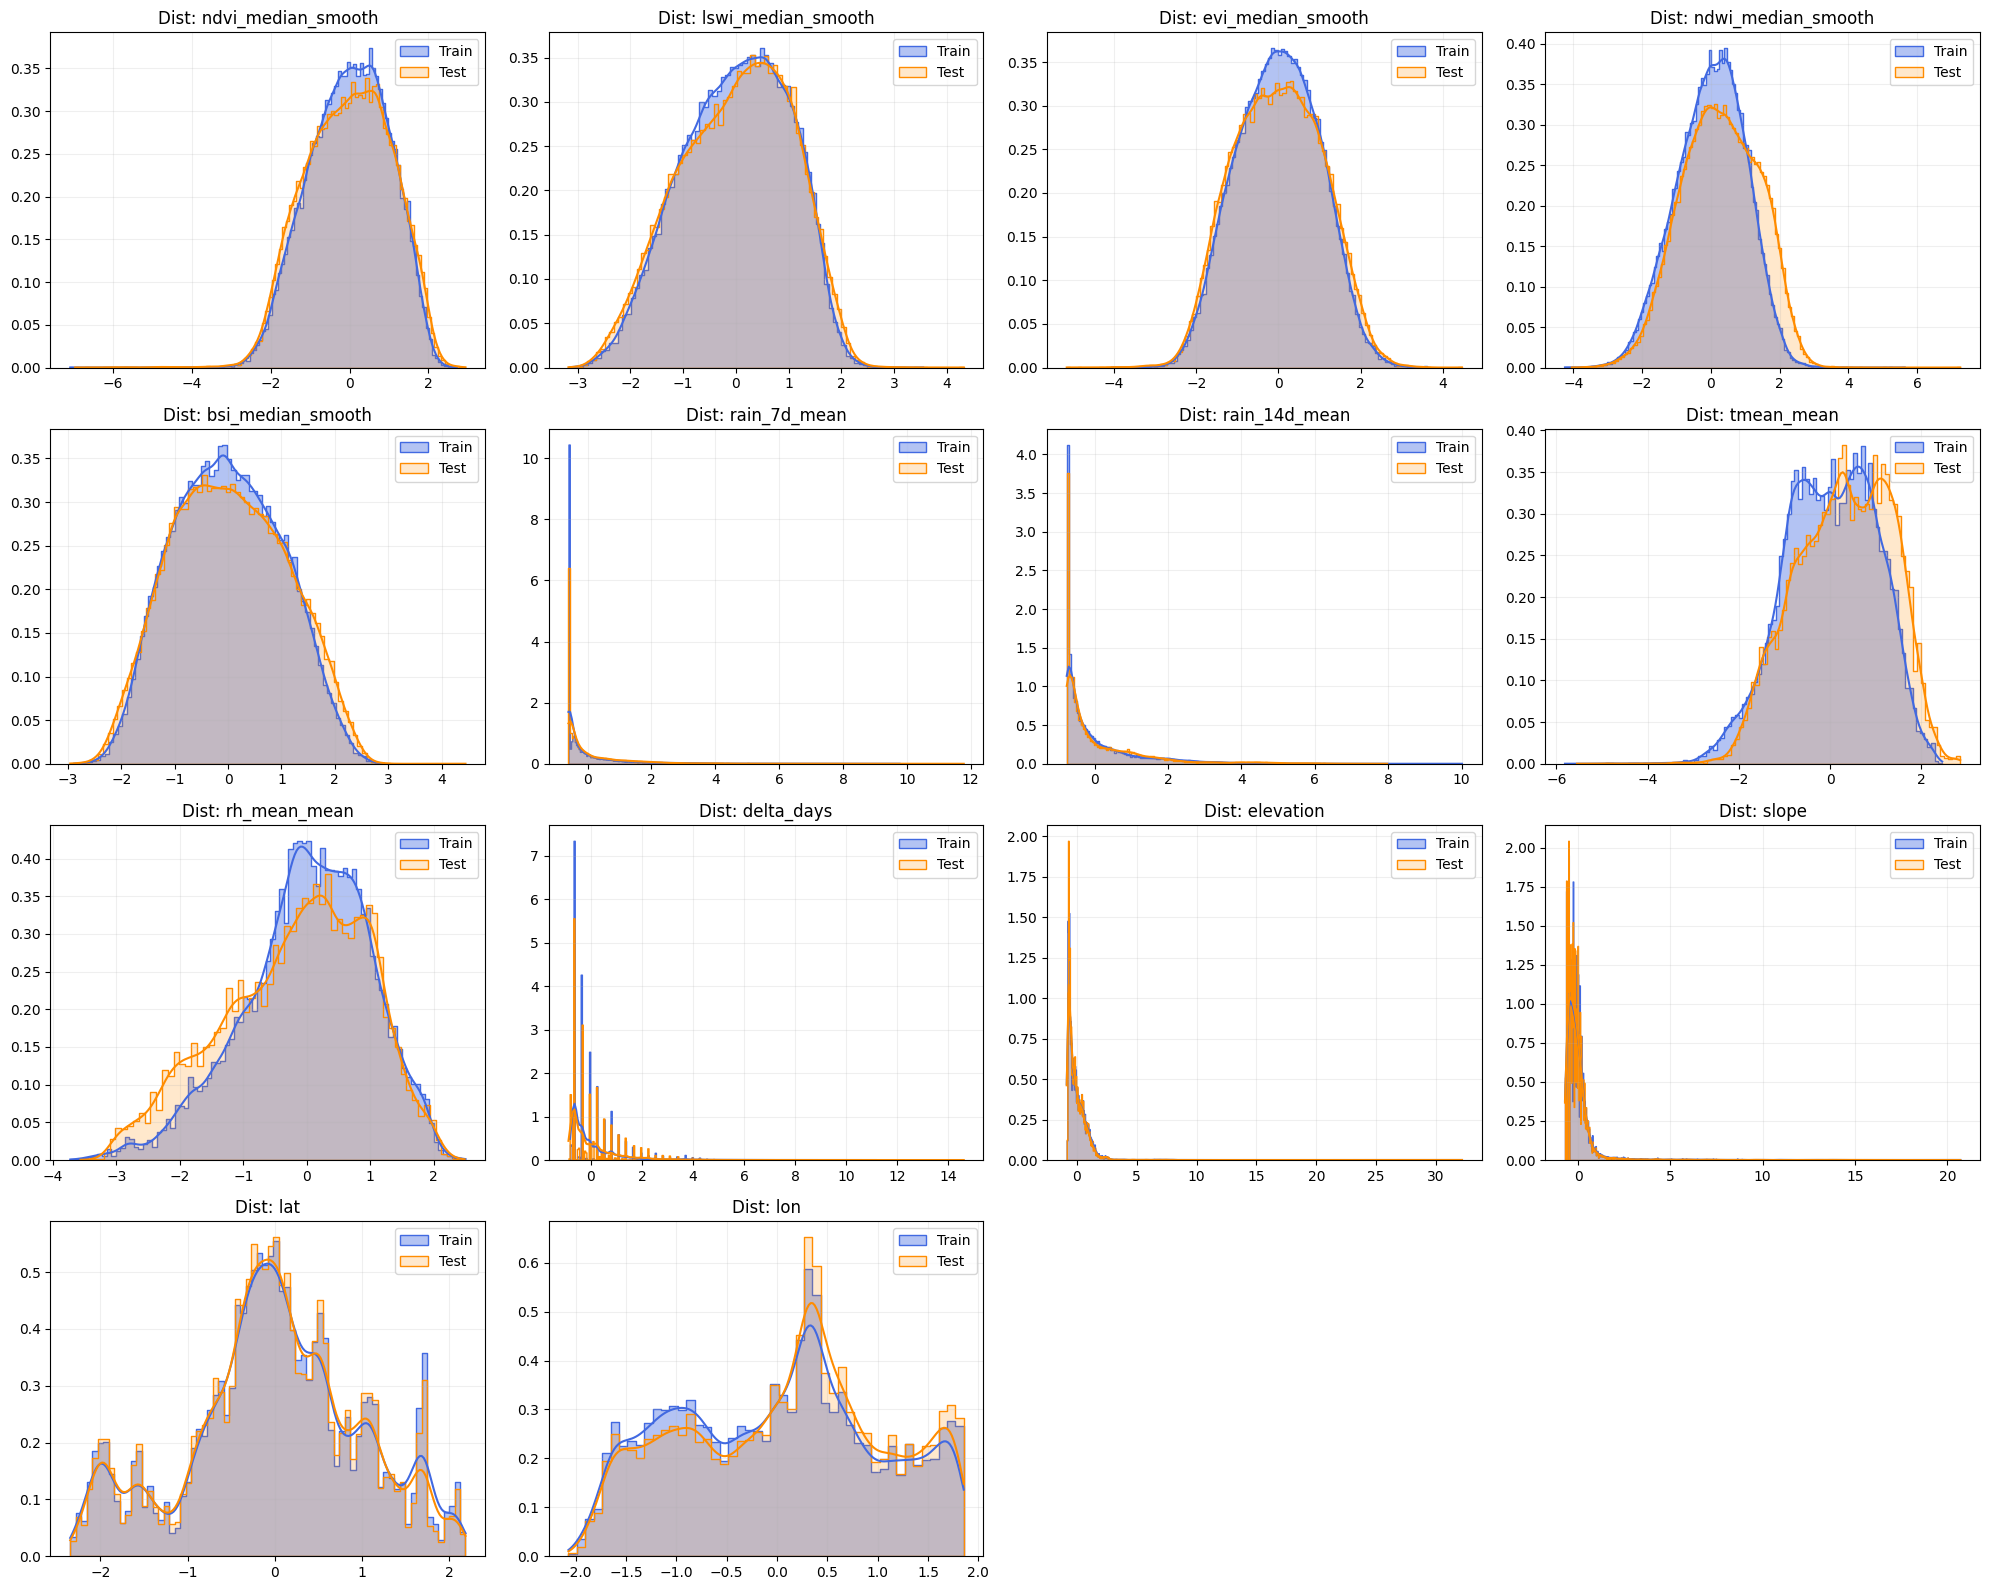

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_train_test_comparison_fast(train_df, test_df, features, cols=4):
    rows = (len(features) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
    axes = axes.flatten()

    # Optimization: Use histplot with a lower element count or subsampling
    # Subsampling to 50,000 rows provides nearly identical distribution shapes 
    # while running 10x-50x faster.
    for i, col in enumerate(features):
        # Determine sample size for speed (min of 50k or total length)
        train_sample = train_df[col].sample(min(50000, len(train_df)))
        test_sample = test_df[col].sample(min(50000, len(test_df)))

        # Plot using histplot with KDE (much faster than raw kdeplot)
        sns.histplot(train_sample, ax=axes[i], label='Train', 
                     color='royalblue', alpha=0.4, kde=True, element="step", stat="density")
        sns.histplot(test_sample, ax=axes[i], label='Test', 
                     color='darkorange', alpha=0.2, kde=True, element="step", stat="density")
        
        axes[i].set_title(f'Dist: {col}', fontsize=12)
        axes[i].legend()
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
        axes[i].grid(True, alpha=0.2)

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig('train_test_optimized.png', dpi=150) # Lower DPI for faster saving
    plt.show()

# Run the optimized version
plot_train_test_comparison_fast(train_df, test_df, features_to_scale)

# **Masking**

<Axes: xlabel='ndvi_zscore', ylabel='Density'>

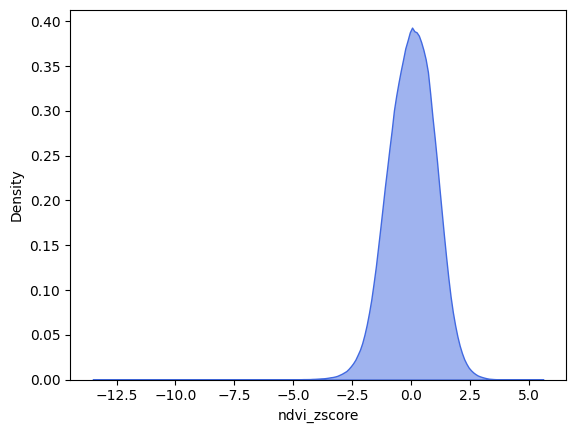

In [40]:
sns.kdeplot(train_df['ndvi_zscore'], fill=True, color='royalblue', alpha=0.5)

<Axes: xlabel='cpi', ylabel='Density'>

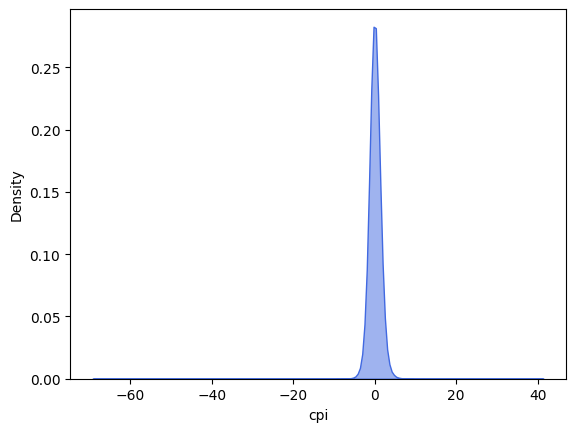

In [41]:
sns.kdeplot(train_df['cpi'], fill=True, color='royalblue', alpha=0.5)

In [42]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1503625 entries, 0 to 2432426
Data columns (total 37 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   pixel_id            1503625 non-null  int32         
 1   date                1503625 non-null  datetime64[ns]
 2   year                1503625 non-null  int64         
 3   stage_name          1503625 non-null  object        
 4   month               1503625 non-null  int64         
 5   season              1503625 non-null  object        
 6   ndvi_median_smooth  1503625 non-null  float64       
 7   lswi_median_smooth  1503625 non-null  float64       
 8   evi_median_smooth   1503625 non-null  float64       
 9   ndwi_median_smooth  1503625 non-null  float64       
 10  bsi_median_smooth   1503625 non-null  float64       
 11  ndvi_vel_z          1503625 non-null  float32       
 12  lswi_vel_z          1503625 non-null  float32       
 13  rain_7d_mean     

In [43]:
train_df[['cpi','ndvi_zscore']].describe()

,cpi,ndvi_zscore
count,1.503625e+06,1.503625e+06
mean,2.163296e-02,-6.723051e-11
std,1.377326e+00,9.955347e-01
min,-6.904050e+01,-1.334123e+01
25%,-8.112921e-01,-6.646374e-01
50%,0.000000e+00,3.106338e-02
75%,8.256702e-01,6.944136e-01
max,4.119560e+01,5.434588e+00


In [44]:
def prepare_gated_data(df):
    # 1. Feature: is_growing (1.0 for Vegetative, Reproductive, Ripening)
    # This helps the model "ignore" NDVI noise during Harvest/Transplant
    df['is_growing'] = df['stage'].isin([1, 2, 3]).astype('float32')
    
    # 2. Target Weight: reg_weight 
    # Used in the loss function to zero-out error during off-season
    df['reg_weight'] = df['is_growing']
    
    # 3. Clean Targets: Keep raw values, just clip outliers
    # We do NOT force these to 0.0 anymore!
    df['ndvi_zscore'] = df['ndvi_zscore'].clip(-4.0, 4.0)
    df['cpi'] = df['cpi'].clip(-4.0, 4.0)
    
    return df

train_df = prepare_gated_data(train_df)
test_df = prepare_gated_data(test_df)

In [45]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1503625 entries, 0 to 2432426
Data columns (total 39 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   pixel_id            1503625 non-null  int32         
 1   date                1503625 non-null  datetime64[ns]
 2   year                1503625 non-null  int64         
 3   stage_name          1503625 non-null  object        
 4   month               1503625 non-null  int64         
 5   season              1503625 non-null  object        
 6   ndvi_median_smooth  1503625 non-null  float64       
 7   lswi_median_smooth  1503625 non-null  float64       
 8   evi_median_smooth   1503625 non-null  float64       
 9   ndwi_median_smooth  1503625 non-null  float64       
 10  bsi_median_smooth   1503625 non-null  float64       
 11  ndvi_vel_z          1503625 non-null  float32       
 12  lswi_vel_z          1503625 non-null  float32       
 13  rain_7d_mean     

In [46]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1074496 entries, 13528 to 2578120
Data columns (total 39 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   pixel_id            1074496 non-null  int32         
 1   date                1074496 non-null  datetime64[ns]
 2   year                1074496 non-null  int64         
 3   stage_name          1074496 non-null  object        
 4   month               1074496 non-null  int64         
 5   season              1074496 non-null  object        
 6   ndvi_median_smooth  1074496 non-null  float64       
 7   lswi_median_smooth  1074496 non-null  float64       
 8   evi_median_smooth   1074496 non-null  float64       
 9   ndwi_median_smooth  1074496 non-null  float64       
 10  bsi_median_smooth   1074496 non-null  float64       
 11  ndvi_vel_z          1074496 non-null  float32       
 12  lswi_vel_z          1074496 non-null  float32       
 13  rain_7d_mean 

<Axes: >

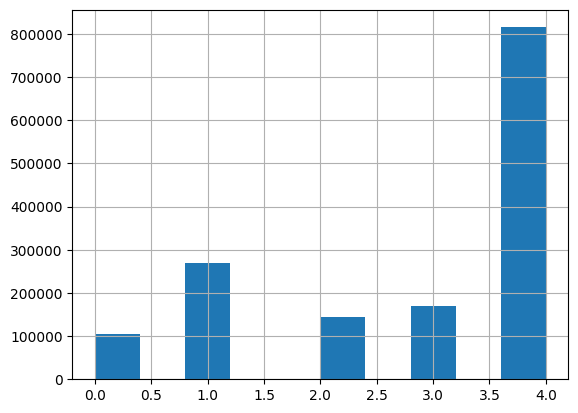

In [47]:
train_df['stage'].hist()

In [48]:
train_df['stage'].value_counts()

stage
4    815568
1    270028
3    169829
2    143327
0    104873
Name: count, dtype: int64

In [49]:
train_df.drop(columns=['stage_name'], inplace=True)
test_df.drop(columns=['stage_name'], inplace=True)

<Axes: xlabel='ndvi_zscore', ylabel='Density'>

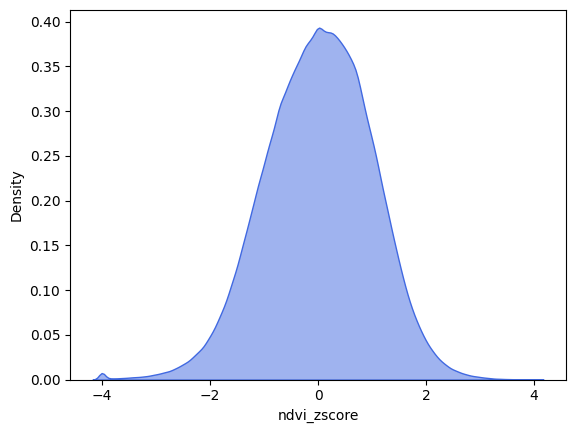

In [50]:
sns.kdeplot(train_df['ndvi_zscore'], fill=True, color='royalblue', alpha=0.5)

<Axes: xlabel='cpi', ylabel='Density'>

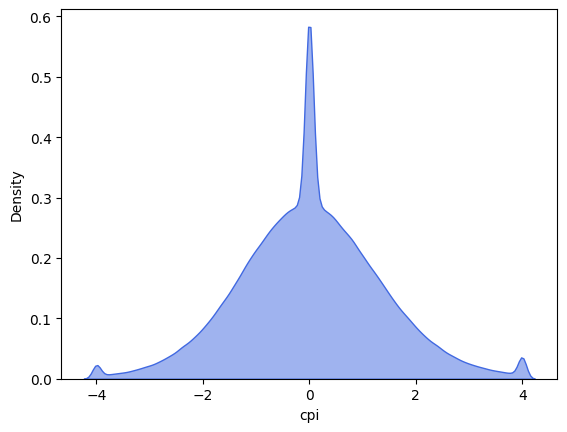

In [51]:
sns.kdeplot(train_df['cpi'], fill=True, color='royalblue', alpha=0.5)

In [52]:
train_df[['cpi','ndvi_zscore']].describe()

,cpi,ndvi_zscore
count,1.503625e+06,1.503625e+06
mean,1.893090e-02,1.251384e-03
std,1.336533e+00,9.887257e-01
min,-4.000000e+00,-4.000000e+00
25%,-8.112921e-01,-6.646374e-01
50%,0.000000e+00,3.106338e-02
75%,8.256702e-01,6.944136e-01
max,4.000000e+00,4.000000e+00


In [53]:
train_df

,pixel_id,date,year,month,season,ndvi_median_smooth,lswi_median_smooth,evi_median_smooth,ndwi_median_smooth,bsi_median_smooth,...,hazard_drought,hazard_flood,hazard_heavy_rain,hazard_landslide,hazard_lightning,hazard_wind,cycle_id,season_id,is_growing,reg_weight
0,0,2022-01-07,2022,1,Maha,1.280867,0.857722,0.871222,-0.452818,-0.926782,...,0,0,0,0,0,0,2021_2022_Maha,0,0.0,0.0
1,62,2022-01-07,2022,1,Maha,2.240264,1.938862,1.549279,-1.923717,-2.205417,...,0,0,0,0,0,0,2021_2022_Maha,0,0.0,0.0
2,102,2022-01-07,2022,1,Maha,-0.208470,1.142383,-0.794373,0.416379,-0.737192,...,0,0,0,0,0,0,2021_2022_Maha,0,0.0,0.0
3,63,2022-01-07,2022,1,Maha,1.235734,1.352366,1.439667,-1.940396,-1.489588,...,0,0,0,0,0,0,2021_2022_Maha,0,0.0,0.0
4,48,2022-01-07,2022,1,Maha,2.123494,1.764179,1.646627,-1.584293,-1.980913,...,0,0,0,0,0,0,2021_2022_Maha,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2432422,65,2024-04-26,2024,4,Maha,-1.052046,1.187784,-1.246020,-0.842194,-0.728288,...,0,0,0,0,0,0,2024_2025_Maha,0,1.0,1.0
2432423,2218,2024-04-26,2024,4,Maha,-1.173570,-0.685115,-1.188038,0.083322,0.736265,...,0,0,0,0,0,0,2024_2025_Maha,0,0.0,0.0
2432424,141,2024-04-26,2024,4,Maha,-0.308179,-0.411157,-0.568975,0.279903,0.443707,...,0,0,0,0,0,0,2024_2025_Maha,0,0.0,0.0
2432425,1266,2024-04-26,2024,4,Maha,-1.201684,0.156616,-1.303291,-0.132252,0.162880,...,0,0,0,0,0,0,2024_2025_Maha,0,1.0,1.0


In [54]:
train_df[hazard_cols]

,hazard_drought,hazard_flood,hazard_heavy_rain,hazard_landslide,hazard_lightning,hazard_wind
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
2432422,0,0,0,0,0,0
2432423,0,0,0,0,0,0
2432424,0,0,0,0,0,0
2432425,0,0,0,0,0,0


# **Creating 3D Sequences**

In [55]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import tensorflow.keras.backend as K

2026-02-15 04:38:49.786863: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771130329.960224      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771130330.018425      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771130330.464189      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771130330.464223      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771130330.464226      55 computation_placer.cc:177] computation placer alr

In [56]:
import numpy as np
import pandas as pd
import tensorflow as tf

# --- 1. UPDATED FEATURE DEFINITIONS ---
# Core temporal features (17)
base_ts_features = [
    'ndvi_median_smooth', 'lswi_median_smooth', 'evi_median_smooth', 
    'ndwi_median_smooth', 'bsi_median_smooth', 'ndvi_vel_z', 'lswi_vel_z', 
    'bsi_z', 'ndvi_zscore', 'rain_7d_mean', 'rain_14d_mean', 'tmean_mean', 
    'rh_mean_mean', 'delta_days', 'doy_sin', 'doy_cos', 'is_growing'
]

hazard_cols = [
    'hazard_drought', 'hazard_flood', 'hazard_heavy_rain', 
    'hazard_landslide', 'hazard_lightning', 'hazard_wind'
]

# Total TS Features = 23 + 2 (New Physics Features) = 25
ts_features = base_ts_features + hazard_cols + ['flood_index', 'ndvi_delta']

# Static features (7) remain the same
static_features = ['lat', 'lon', 'elevation', 'slope', 'season_id', 'doy_sin', 'doy_cos']

def fast_sequencing_v7(df, window_size=10):
    # Sort to ensure temporal consistency
    df = df.sort_values(['pixel_id', 'cycle_id', 'date']).reset_index(drop=True)
    df['group_id'] = df.groupby(['pixel_id', 'cycle_id']).ngroup()
    
    # --- 1. NEW PHYSICS FEATURES ---
    # High Flood Index = Water (Transplant); Low = Bare Soil (Harvest)
    df['flood_index'] = df['lswi_median_smooth'] - df['ndvi_median_smooth']
    
    # Change in NDVI (Helps distinguish growth start vs growth end)
    df['ndvi_delta'] = df.groupby('pixel_id')['ndvi_median_smooth'].diff().fillna(0)
    
    # Binary flag: 1 if growing (Stages 1,2,3), 0 if off-season (0,4)
    df['is_growing'] = df['stage'].isin([1, 2, 3]).astype('float32')
    
    # Target Values
    y_health_raw = df['ndvi_zscore'].clip(-4.0, 4.0).fillna(0.0).values
    y_pest_raw = df['cpi'].clip(-4.0, 4.0).fillna(0.0).values

    # --- 2. SEQUENCING LOGIC ---
    ts_data = df[ts_features].values.astype('float32')
    static_data = df[static_features].values.astype('float32')
    dist_data = df['district_id'].values.astype('int32')
    
    y_stage_arr = df['stage'].values.astype('int32')
    group_ids = df['group_id'].values
    is_growing_arr = df['is_growing'].values.astype('float32')

    total_rows = len(df)
    starts = np.arange(total_rows - window_size + 1)
    ends = starts + window_size - 1
    
    valid_mask = (group_ids[starts] == group_ids[ends])
    valid_starts = starts[valid_mask]
    valid_ends = valid_starts + window_size - 1
    indices_2d = valid_starts[:, None] + np.arange(window_size)[None, :]

    X = {
        "temporal_input": ts_data[indices_2d],
        "static_input": static_data[valid_ends],
        "district_input": dist_data[valid_ends]
    }
    Y = {
        "stage_out": y_stage_arr[valid_ends],
        "health_out": y_health_raw[valid_ends],
        "pest_out": y_pest_raw[valid_ends]
    }
    W = {
        "stage_out": np.ones(len(valid_ends), dtype='float32'),
        "health_out": is_growing_arr[valid_ends],
        "pest_out": is_growing_arr[valid_ends]
    }

    return X, Y, W

# --- 2. DATASET CREATION ---
print("🔄 Creating sequences (Hazard-as-Input)...")
X_train, Y_train, W_train = fast_sequencing_v7(train_df)
X_test, Y_test, W_test = fast_sequencing_v7(test_df)

train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train, W_train))\
    .shuffle(150000)\
    .batch(1024)\
    .prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, Y_test, W_test))\
    .batch(1024)\
    .prefetch(tf.data.AUTOTUNE)

print(f"✅ Created {len(X_train['temporal_input'])} training samples.")
print(f"✅ Input shape: {X_train['temporal_input'].shape}") # Should be (N, 10, 23)

🔄 Creating sequences (Hazard-as-Input)...


I0000 00:00:1771130347.689777      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ Created 1274113 training samples.
✅ Input shape: (1274113, 10, 25)


In [57]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if len(tf.config.list_physical_devices('GPU')) == 0:
    print("WARNING: No GPU found. Training will be very slow on CPU.")
else:
    print("SUCCESS: GPU is ready for RiceVision training.")

Num GPUs Available:  1
SUCCESS: GPU is ready for RiceVision training.


In [58]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1503625 entries, 0 to 2432426
Data columns (total 38 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   pixel_id            1503625 non-null  int32         
 1   date                1503625 non-null  datetime64[ns]
 2   year                1503625 non-null  int64         
 3   month               1503625 non-null  int64         
 4   season              1503625 non-null  object        
 5   ndvi_median_smooth  1503625 non-null  float64       
 6   lswi_median_smooth  1503625 non-null  float64       
 7   evi_median_smooth   1503625 non-null  float64       
 8   ndwi_median_smooth  1503625 non-null  float64       
 9   bsi_median_smooth   1503625 non-null  float64       
 10  ndvi_vel_z          1503625 non-null  float32       
 11  lswi_vel_z          1503625 non-null  float32       
 12  rain_7d_mean        1503625 non-null  float64       
 13  rain_14d_mean    

In [59]:
train_df['stage'].value_counts(normalize=True)

stage
4    0.542401
1    0.179585
3    0.112946
2    0.095321
0    0.069747
Name: proportion, dtype: float64

In [60]:
test_df['stage'].value_counts(normalize=True)

stage
4    0.502515
1    0.201561
3    0.128055
2    0.108180
0    0.059689
Name: proportion, dtype: float64

<Axes: >

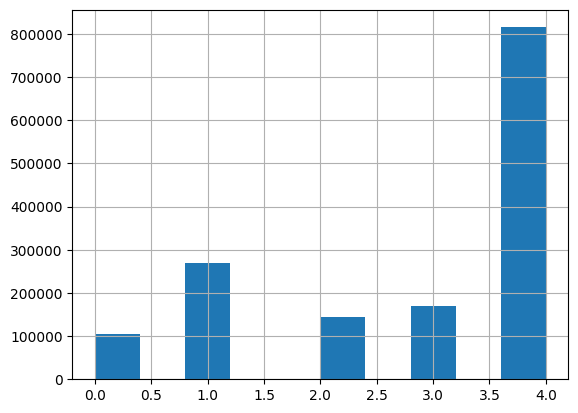

In [61]:
train_df['stage'].hist()

<Axes: >

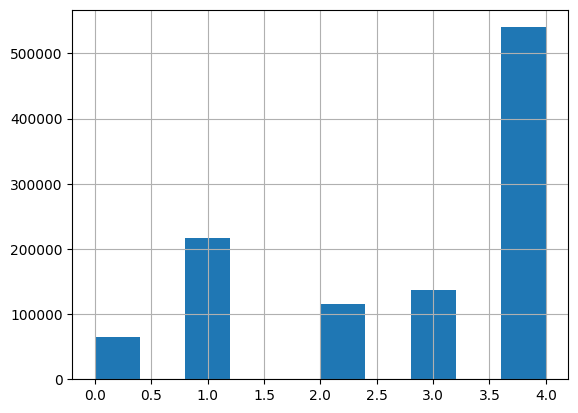

In [62]:
test_df['stage'].hist()

In [63]:
train_df[hazard_cols]

,hazard_drought,hazard_flood,hazard_heavy_rain,hazard_landslide,hazard_lightning,hazard_wind
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
2432422,0,0,0,0,0,0
2432423,0,0,0,0,0,0
2432424,0,0,0,0,0,0
2432425,0,0,0,0,0,0


--- Hazard Frequency (Counts & Percentage) ---
                   Count  Percentage
hazard_wind        22893        1.52
hazard_heavy_rain   8974        0.60
hazard_flood        4608        0.31
hazard_lightning    3937        0.26
hazard_drought       725        0.05
hazard_landslide     417        0.03


/tmp/ipykernel_55/1670407107.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hazard_summary['Count'], y=hazard_summary.index, palette='viridis')


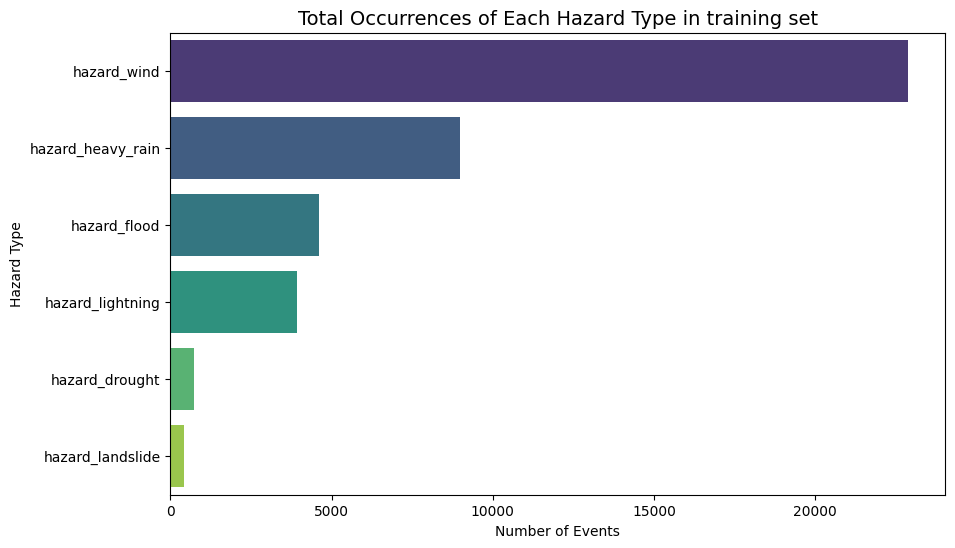

In [64]:
print("--- Hazard Frequency (Counts & Percentage) ---")
hazard_summary = pd.DataFrame({
    'Count': train_df[hazard_cols].sum(),
    'Percentage': (train_df[hazard_cols].mean() * 100).round(2)
}).sort_values('Count', ascending=False)
print(hazard_summary)

# 2. Visualization: Total Counts of Each Hazard
plt.figure(figsize=(10, 6))
sns.barplot(x=hazard_summary['Count'], y=hazard_summary.index, palette='viridis')
plt.title('Total Occurrences of Each Hazard Type in training set', fontsize=14)
plt.xlabel('Number of Events')
plt.ylabel('Hazard Type')
plt.show()

--- Hazard Frequency (Counts & Percentage) ---


/tmp/ipykernel_55/4267890342.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hazard_summary['Count'], y=hazard_summary.index, palette='viridis')


                   Count  Percentage
hazard_wind        16193        1.51
hazard_lightning    3816        0.36
hazard_heavy_rain   2352        0.22
hazard_flood         706        0.07
hazard_drought       379        0.04
hazard_landslide      56        0.01


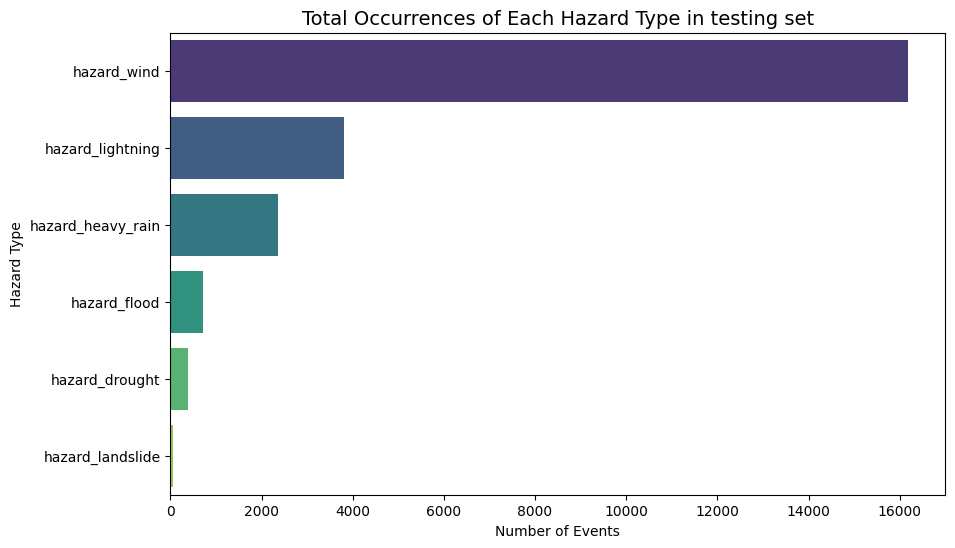

In [65]:
print("--- Hazard Frequency (Counts & Percentage) ---")
hazard_summary = pd.DataFrame({
    'Count': test_df[hazard_cols].sum(),
    'Percentage': (test_df[hazard_cols].mean() * 100).round(2)
}).sort_values('Count', ascending=False)
print(hazard_summary)

# 2. Visualization: Total Counts of Each Hazard
plt.figure(figsize=(10, 6))
sns.barplot(x=hazard_summary['Count'], y=hazard_summary.index, palette='viridis')
plt.title('Total Occurrences of Each Hazard Type in testing set', fontsize=14)
plt.xlabel('Number of Events')
plt.ylabel('Hazard Type')
plt.show()

In [66]:
# Run this before sequencing to see if your targets are crazy
print(df[['ndvi_zscore', 'cpi']].describe())

        ndvi_zscore           cpi
count  2.578121e+06  2.578121e+06
mean   1.355463e-09  1.846598e-02
std    9.960734e-01  1.396445e+00
min   -1.466438e+01 -6.904050e+01
25%   -6.626248e-01 -8.273878e-01
50%    2.958939e-02  0.000000e+00
75%    6.902285e-01  8.335552e-01
max    5.434588e+00  4.837301e+01


# **LSTM model building**

In [67]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, backend as K

# --- 1. OPTIMIZED LOSS FUNCTIONS (NO MASKING) ---

def weighted_stage_ce_v2(y_true, y_pred):
    """
    Revised weights to reduce "Transplant" false positives.
    Instead of 8.0, we use 3.0 to balance importance with reality.
    Weights: [0: Transplant, 1: Vegetative, 2: Reproductive, 3: Ripening, 4: Harvest]
    """
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
    # 4.0 for Reproductive (critical for yield) and 3.0 for Transplant
    class_weights = tf.constant([3.0, 1.5, 4.0, 1.5, 1.0], dtype=tf.float32)
    weights = tf.gather(class_weights, y_true)
    
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    return tf.reduce_mean(loss * weights)

def robust_huber_loss(y_true, y_pred):
    """Robust to NDVI outliers, smooth gradients for precise Z-scores."""
    return tf.keras.losses.Huber(delta=1.0)(y_true, y_pred)

# --- 2. CUSTOM METRICS ---

def regression_accuracy(y_true, y_pred):
    """Calculates % of predictions within 0.5 of the actual value."""
    diff = tf.abs(tf.squeeze(y_true) - tf.squeeze(y_pred))
    return tf.reduce_mean(tf.cast(diff < 0.5, tf.float32))

# --- 3. ARCHITECTURE WITH ATTENTION ---

def build_rice_vision_v7(window_size=10, ts_count=25, static_count=7):
    """
    V7 Architecture: 
    1. Physics-based: Uses 25 features (inc. flood_index, ndvi_delta)
    2. District-Aware: Embedding handles local calendar shifts.
    3. Wide Shortcut: Direct connection from District/Time to Stage Head.
    """
    l2_reg = regularizers.l2(1e-4)
    
    # Inputs
    temp_in = layers.Input(shape=(window_size, ts_count), name="temporal_input")
    stat_in = layers.Input(shape=(static_count,), name="static_input") # DOY and Season
    dist_in = layers.Input(shape=(1,), name="district_input")

    # 1. Local Bias (District Embedding)
    # Increased to 12-dim to capture more complex regional timing differences
    d_emb = layers.Embedding(input_dim=26, output_dim=12)(dist_in)
    d_flat = layers.Flatten()(d_emb)

    # 2. Temporal Path (LSTM + Attention) - "The Physics"
    x = layers.SpatialDropout1D(0.2)(temp_in) # Increased dropout to fight overfitting
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    
    attn_out = layers.MultiHeadAttention(num_heads=4, key_dim=128)(x, x)
    x = layers.Add()([x, attn_out]) 
    x = layers.LayerNormalization()(x)
    
    # Pooling captures the state of the 10-day window
    x_max = layers.GlobalMaxPooling1D()(x)
    x_avg = layers.GlobalAveragePooling1D()(x)
    lstm_feat = layers.concatenate([x_max, x_avg])

    # 3. Wide Path (The Local Calendar Logic)
    # This combines District + Time directly to bypass LSTM memory issues
    wide_context = layers.concatenate([d_flat, stat_in])
    wide_feat = layers.Dense(64, activation='relu', kernel_regularizer=l2_reg)(wide_context)
    wide_feat = layers.BatchNormalization()(wide_feat)

    # 4. Fusion Layer
    combined = layers.concatenate([lstm_feat, wide_feat])
    combined = layers.Dense(256, activation='relu', kernel_regularizer=l2_reg)(combined)
    combined = layers.Dropout(0.5)(combined) # Higher dropout for better generalization

    # 5. Adaptive Heads
    # The Stage head gets a "Skip Connection" to the wide_feat (Local Calendar)
    stage_combined = layers.concatenate([combined, wide_feat])
    stage_out = layers.Dense(5, activation='softmax', name='stage_out')(stage_combined)
    
    # Regression heads use the fused features
    health_out = layers.Dense(1, name='health_out')(combined)
    pest_out = layers.Dense(1, name='pest_out')(combined)

    return models.Model(inputs=[temp_in, stat_in, dist_in], 
                        outputs=[stage_out, health_out, pest_out])

In [68]:
# --- 4. COMPILE & TRAIN ---

model = build_rice_vision_v7(window_size=10, ts_count=25, static_count=7)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss={
        "stage_out": weighted_stage_ce_v2,
        "health_out": robust_huber_loss,
        "pest_out": robust_huber_loss,
       
    },
    loss_weights={
        "stage_out": 4.0,      # Foundation
        "health_out": 1.0,
        "pest_out": 1.0
    },
    metrics={
        "stage_out": "accuracy",
        "health_out": [regression_accuracy, "mae"],
        "pest_out": [regression_accuracy, "mae"],
        
    }
)

print(model.summary())

MODEL_NAME = "ricevision_v7_district_aware.keras"
def transform_to_tuple(x_dict, y_dict, w_dict=None):
    """
    Rearranges the dictionary dataset into tuples for model.fit.
    Order must match the Model's inputs and outputs.
    """
    # 1. Inputs: Must match names in build_rice_vision_optimized
    x_tuple = (
        x_dict["temporal_input"], 
        x_dict["static_input"], 
        x_dict["district_input"]
    )
    
    # 2. Outputs: Must match the order of 'outputs' in Model definition
    # Order: [stage_out, health_out, pest_out, disaster_out]
    y_tuple = (
        y_dict["stage_out"], 
        y_dict["health_out"], 
        y_dict["pest_out"], 
        
    )
    
    # 3. Weights: This uses the 'reg_weight' (is_growing) to gate the loss
    # If w_dict isn't provided by your data loader, Keras defaults to 1.0
    if w_dict:
        w_tuple = (
            w_dict["stage_out"], 
            w_dict["health_out"], # This will be 0.0 for off-season
            w_dict["pest_out"],   # This will be 0.0 for off-season
            
        )
        return x_tuple, y_tuple, w_tuple
    
    return x_tuple, y_tuple

# --- APPLY THE TRANSFORMATION ---
# Assuming your original datasets are named 'train_ds' and 'test_ds'
train_ds_tuple = train_ds.map(transform_to_tuple).prefetch(tf.data.AUTOTUNE)
test_ds_tuple = test_ds.map(transform_to_tuple).prefetch(tf.data.AUTOTUNE)

print("✅ Datasets successfully adapted for Multi-Head Training.")
# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(MODEL_NAME, monitor='val_stage_out_accuracy', save_best_only=True, mode='max'),
    tf.keras.callbacks.CSVLogger("v7_district_aware_log.csv")
]

print("🚀 Starting District-Aware Training...")
# Assuming train_ds_tuple and test_ds_tuple are already mapped
history = model.fit(train_ds_tuple, validation_data=test_ds_tuple, epochs=50, callbacks=callbacks)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ temporal_input      │ (None, 10, 25)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 10, 25)    │          0 │ temporal_input[0… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 10, 256)   │    157,696 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ district_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 256)   │    526,080 │ bidirectional[0]… │
│ (MultiHeadAttentio… │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 12)     │        312 │ district_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 256)   │          0 │ bidirectional[0]… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 12)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 10, 256)   │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 19)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ layer_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,280 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 576)       │          0 │ concatenate[0][0… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 835,967 (3.19 MB)

 Trainable params: 835,839 (3.19 MB)

 Non-trainable params: 128 (512.00 B)

None
✅ Datasets successfully adapted for Multi-Head Training.
🚀 Starting District-Aware Training...
Epoch 1/50


I0000 00:00:1771130364.027733     126 cuda_dnn.cc:529] Loaded cuDNN version 91002


1245/1245 ━━━━━━━━━━━━━━━━━━━━ 98s 71ms/step - health_out_loss: 0.1268 - health_out_mae: 0.6744 - health_out_regression_accuracy: 0.4911 - loss: 5.6881 - pest_out_loss: 0.1994 - pest_out_mae: 0.8992 - pest_out_regression_accuracy: 0.3910 - stage_out_accuracy: 0.6827 - stage_out_loss: 1.3309 - val_health_out_loss: 0.0189 - val_health_out_mae: 0.2203 - val_health_out_regression_accuracy: 0.9216 - val_loss: 2.8093 - val_pest_out_loss: 0.0308 - val_pest_out_mae: 0.2852 - val_pest_out_regression_accuracy: 0.8415 - val_stage_out_accuracy: 0.8148 - val_stage_out_loss: 0.6801 - learning_rate: 3.0000e-04
Epoch 2/50
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 86s 69ms/step - health_out_loss: 0.0443 - health_out_mae: 0.3648 - health_out_regression_accuracy: 0.7505 - loss: 3.1983 - pest_out_loss: 0.0766 - pest_out_mae: 0.4909 - pest_out_regression_accuracy: 0.6293 - stage_out_accuracy: 0.8242 - stage_out_loss: 0.7596 - val_health_out_loss: 0.0173 - val_health_out_mae: 0.2113 - val_health_out_regression_accurac

In [69]:
print(history.history.keys())

dict_keys(['health_out_loss', 'health_out_mae', 'health_out_regression_accuracy', 'loss', 'pest_out_loss', 'pest_out_mae', 'pest_out_regression_accuracy', 'stage_out_accuracy', 'stage_out_loss', 'val_health_out_loss', 'val_health_out_mae', 'val_health_out_regression_accuracy', 'val_loss', 'val_pest_out_loss', 'val_pest_out_mae', 'val_pest_out_regression_accuracy', 'val_stage_out_accuracy', 'val_stage_out_loss', 'learning_rate'])


# **overall Evaluation**

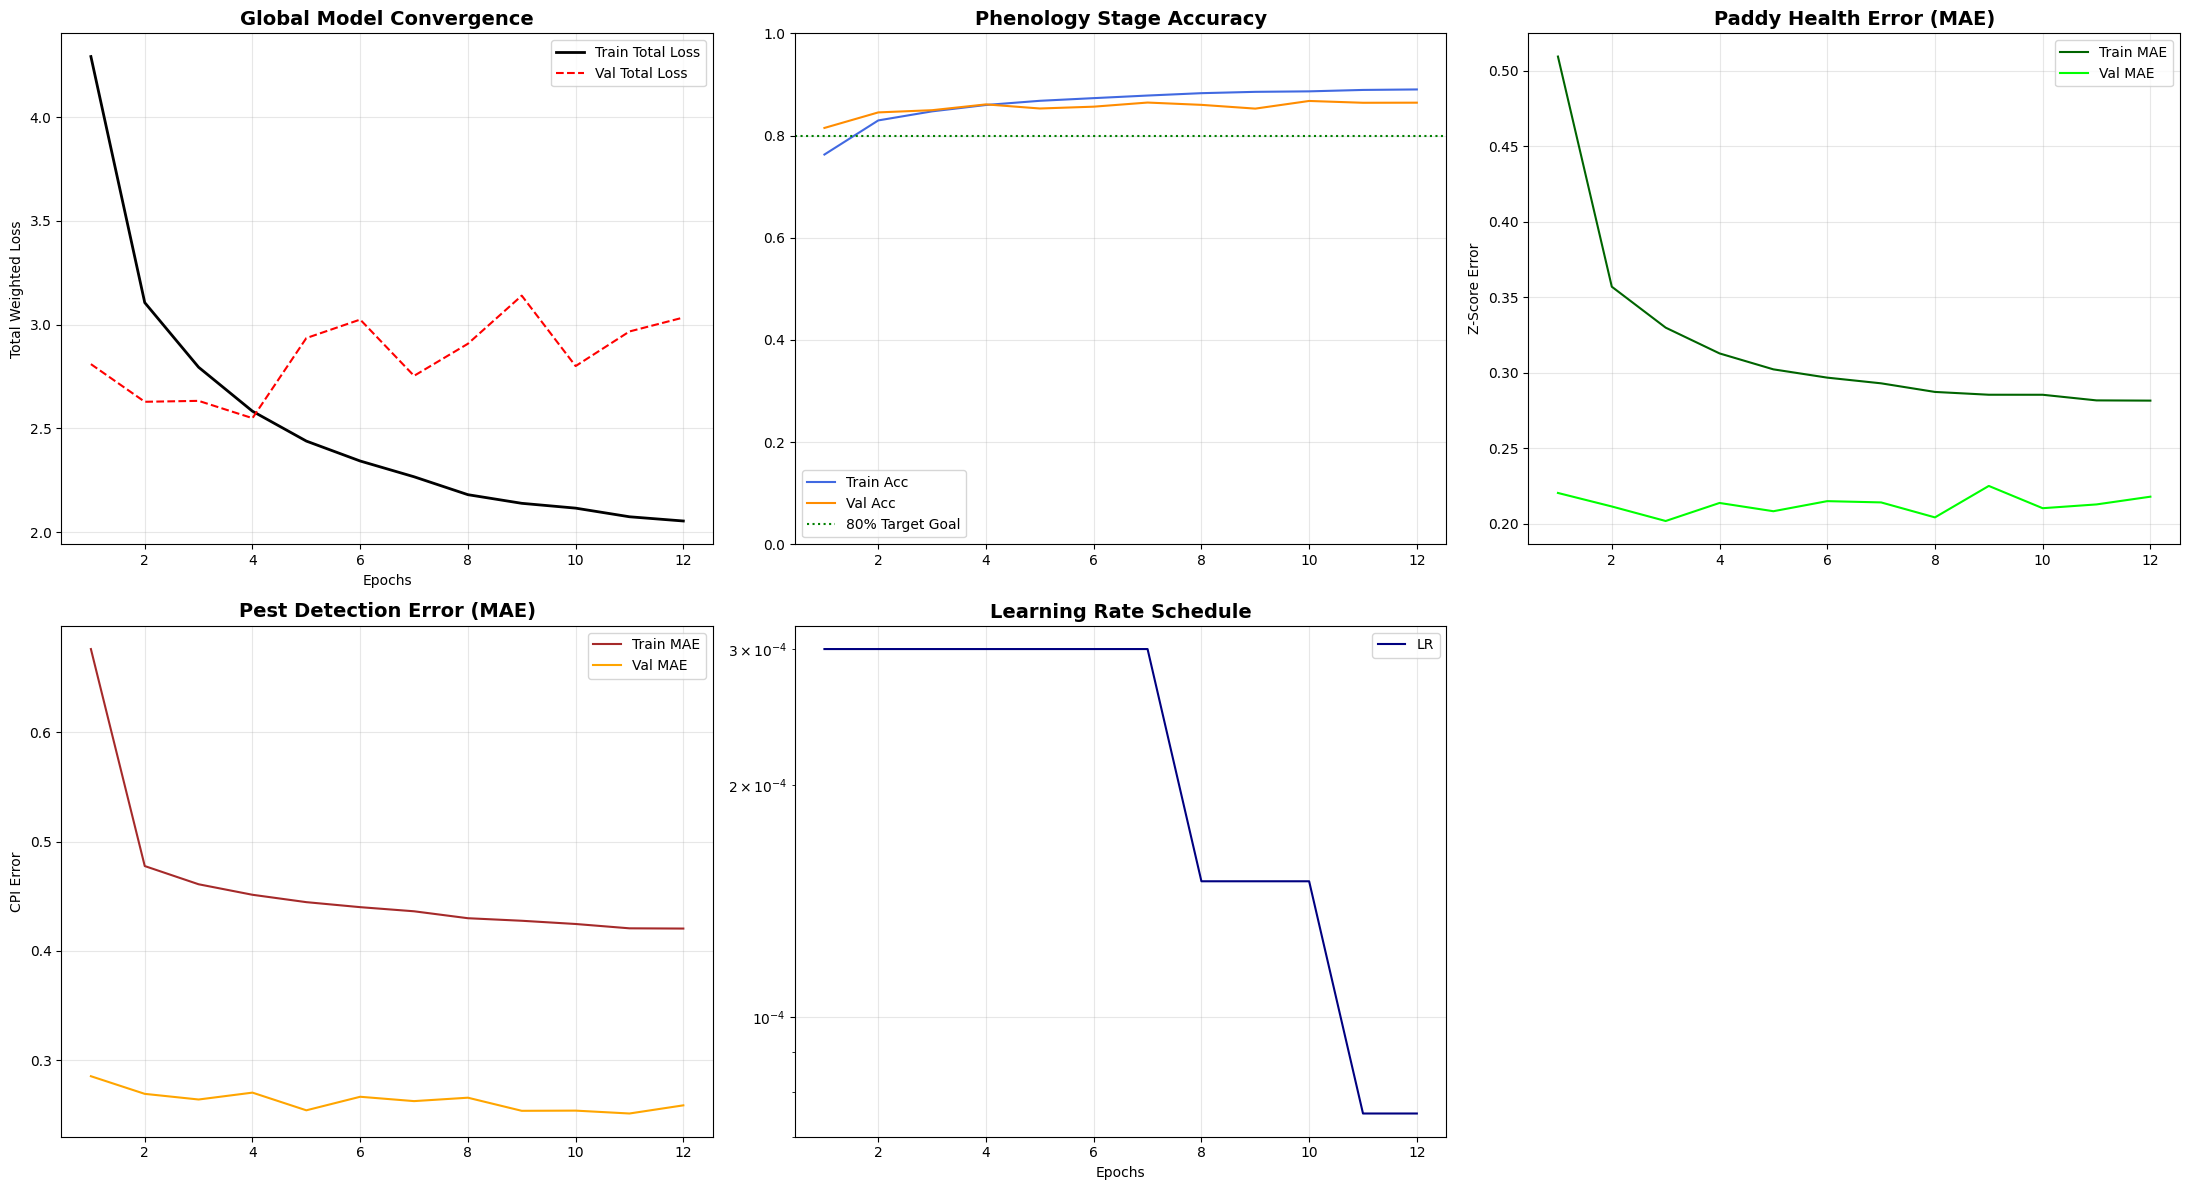

In [70]:
import matplotlib.pyplot as plt

def plot_ricevision_results(history):
    # 2x3 grid to show all heads and the optimizer behavior
    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    axes = axes.flatten()
    h = history.history
    epochs = range(1, len(h['loss']) + 1)

    # 1. GLOBAL LOSS (Weighted Sum)
    axes[0].plot(epochs, h['loss'], label='Train Total Loss', color='black', linewidth=2)
    axes[0].plot(epochs, h['val_loss'], label='Val Total Loss', color='red', linestyle='--')
    axes[0].set_title('Global Model Convergence', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Total Weighted Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2. PHENOLOGY STAGE ACCURACY
    axes[1].plot(epochs, h['stage_out_accuracy'], label='Train Acc', color='royalblue')
    axes[1].plot(epochs, h['val_stage_out_accuracy'], label='Val Acc', color='darkorange')
    axes[1].axhline(y=0.8, color='green', linestyle=':', label='80% Target Goal') 
    axes[1].set_title('Phenology Stage Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # 3. PADDY HEALTH ERROR (NDVI Z-Score)
    axes[2].plot(epochs, h['health_out_mae'], label='Train MAE', color='darkgreen')
    axes[2].plot(epochs, h['val_health_out_mae'], label='Val MAE', color='lime')
    axes[2].set_title('Paddy Health Error (MAE)', fontsize=14, fontweight='bold')
    axes[2].set_ylabel('Z-Score Error')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    # 4. PEST RISK ERROR (CPI Index)
    axes[3].plot(epochs, h['pest_out_mae'], label='Train MAE', color='brown')
    axes[3].plot(epochs, h['val_pest_out_mae'], label='Val MAE', color='orange')
    axes[3].set_title('Pest Detection Error (MAE)', fontsize=14, fontweight='bold')
    axes[3].set_ylabel('CPI Error')
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)

    # 5. LEARNING RATE SCHEDULE
    lr_key = 'learning_rate' if 'learning_rate' in h else 'lr'
    if lr_key in h:
        axes[4].plot(epochs, h[lr_key], color='navy', label='LR')
        axes[4].set_yscale('log')
        axes[4].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
        axes[4].set_xlabel('Epochs')
        axes[4].legend()
        axes[4].grid(True, alpha=0.3)
    axes[5].axis('off')

    plt.tight_layout()
    plt.savefig('ricevision_v3_balanced_results.png', dpi=300)
    plt.show()
plot_ricevision_results(history)

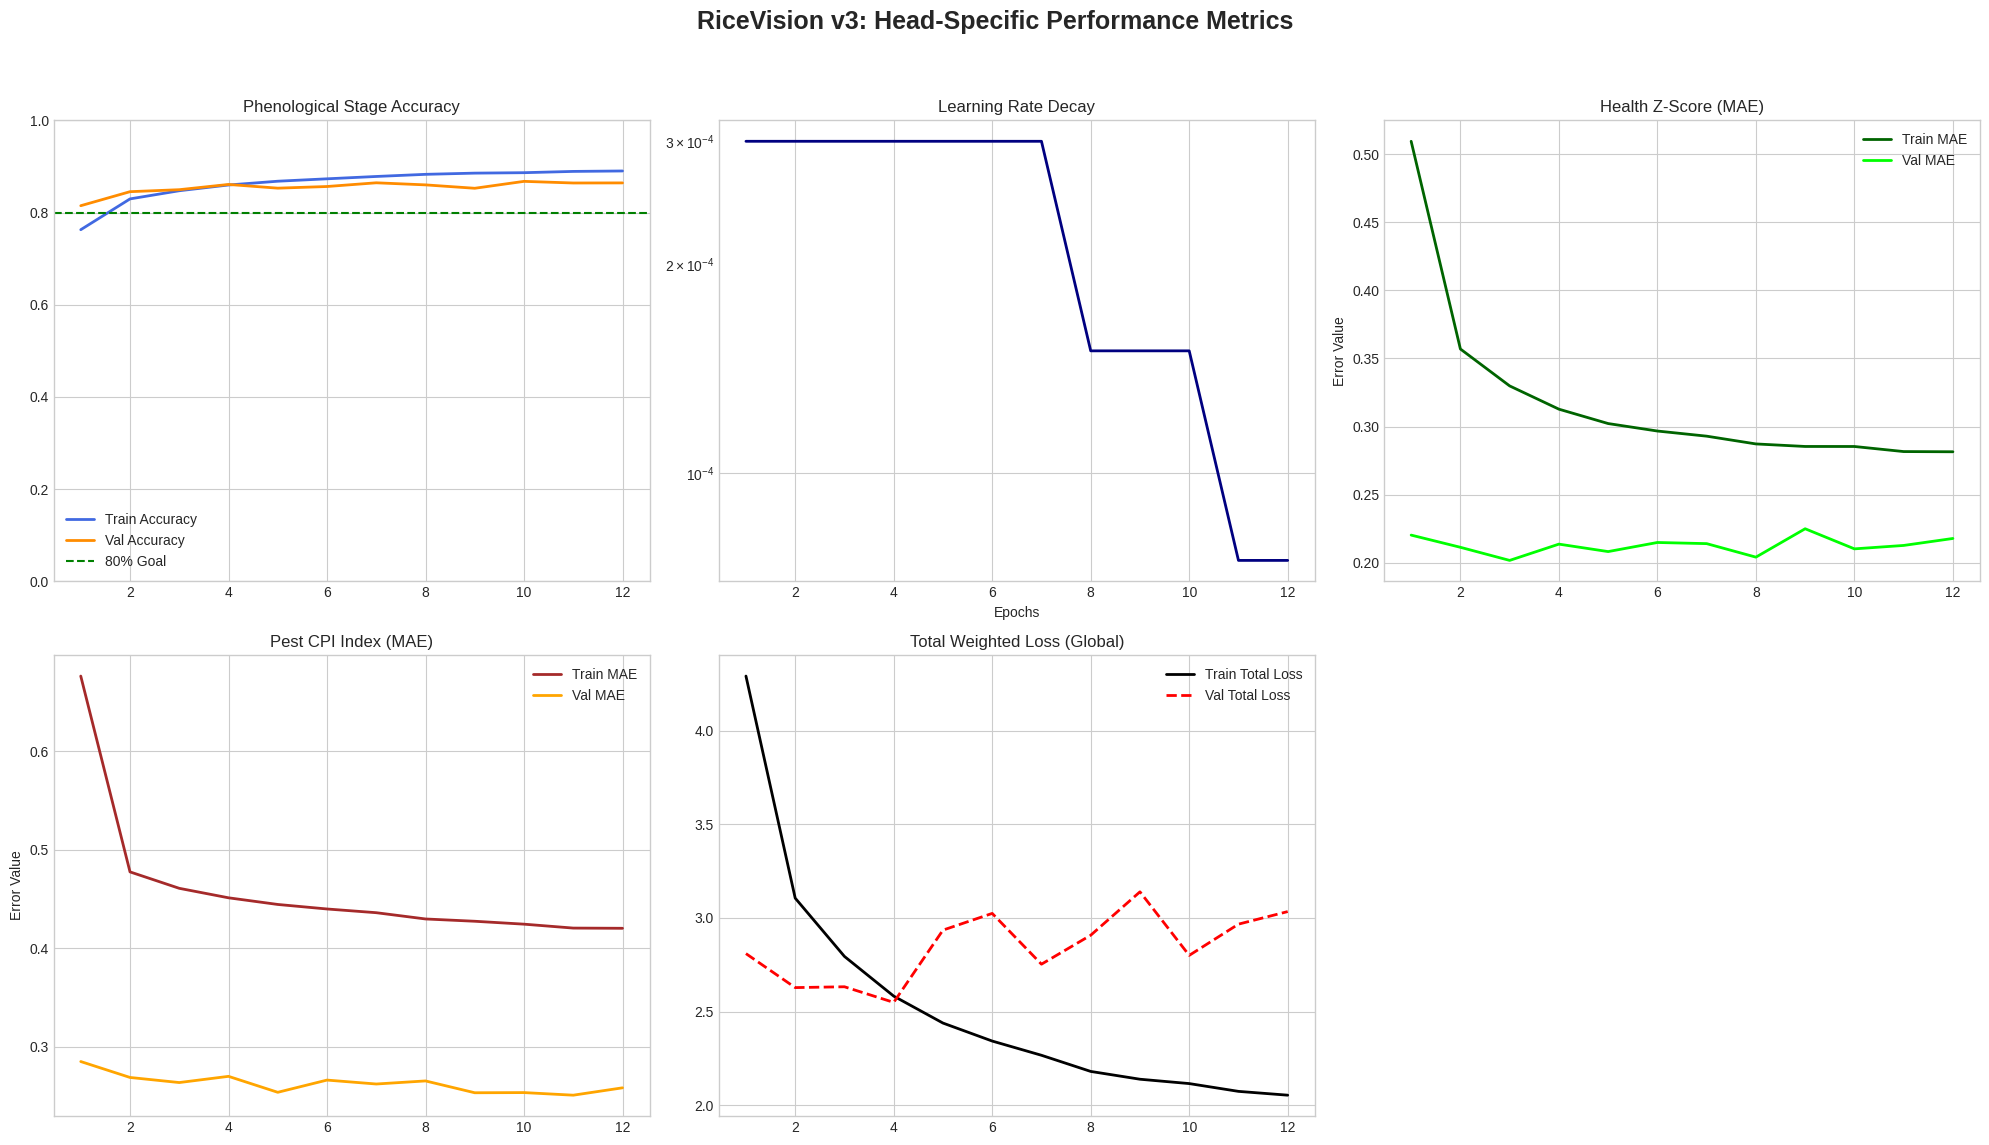

In [71]:
def plot_final_performance_v3(history):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('RiceVision v3: Head-Specific Performance Metrics', fontsize=18, fontweight='bold')
    axes = axes.flatten()
    h = history.history
    epochs = range(1, len(h['loss']) + 1)

    # 1. Phenology Stage Accuracy
    axes[0].plot(epochs, h['stage_out_accuracy'], label='Train Accuracy', color='royalblue', linewidth=2)
    axes[0].plot(epochs, h['val_stage_out_accuracy'], label='Val Accuracy', color='darkorange', linewidth=2)
    axes[0].axhline(y=0.8, color='green', linestyle='--', label='80% Goal')
    axes[0].set_title('Phenological Stage Accuracy')
    axes[0].set_ylim(0, 1)
    axes[0].legend()

    # 3. Learning Rate Schedule
    lr_key = 'learning_rate' if 'learning_rate' in h else 'lr'
    if lr_key in h:
        axes[1].plot(epochs, h[lr_key], color='navy', linewidth=2)
        axes[1].set_yscale('log')
        axes[1].set_title('Learning Rate Decay')
        axes[1].set_xlabel('Epochs')

    # 4. Paddy Health (MAE)
    axes[2].plot(epochs, h['health_out_mae'], label='Train MAE', color='darkgreen', linewidth=2)
    axes[2].plot(epochs, h['val_health_out_mae'], label='Val MAE', color='lime', linewidth=2)
    axes[2].set_title('Health Z-Score (MAE)')
    axes[2].set_ylabel('Error Value')
    axes[2].legend()

    # 5. Pest Risk (MAE)
    axes[3].plot(epochs, h['pest_out_mae'], label='Train MAE', color='brown', linewidth=2)
    axes[3].plot(epochs, h['val_pest_out_mae'], label='Val MAE', color='orange', linewidth=2)
    axes[3].set_title('Pest CPI Index (MAE)')
    axes[3].set_ylabel('Error Value')
    axes[3].legend()

    # 6. Global Model Loss
    axes[4].plot(epochs, h['loss'], label='Train Total Loss', color='black', linewidth=2)
    axes[4].plot(epochs, h['val_loss'], label='Val Total Loss', color='red', linestyle='--', linewidth=2)
    axes[4].set_title('Total Weighted Loss (Global)')
    axes[4].legend()
    axes[5].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('performance_metrics_raw.png', dpi=300)
    plt.show()
plot_final_performance_v3(history)

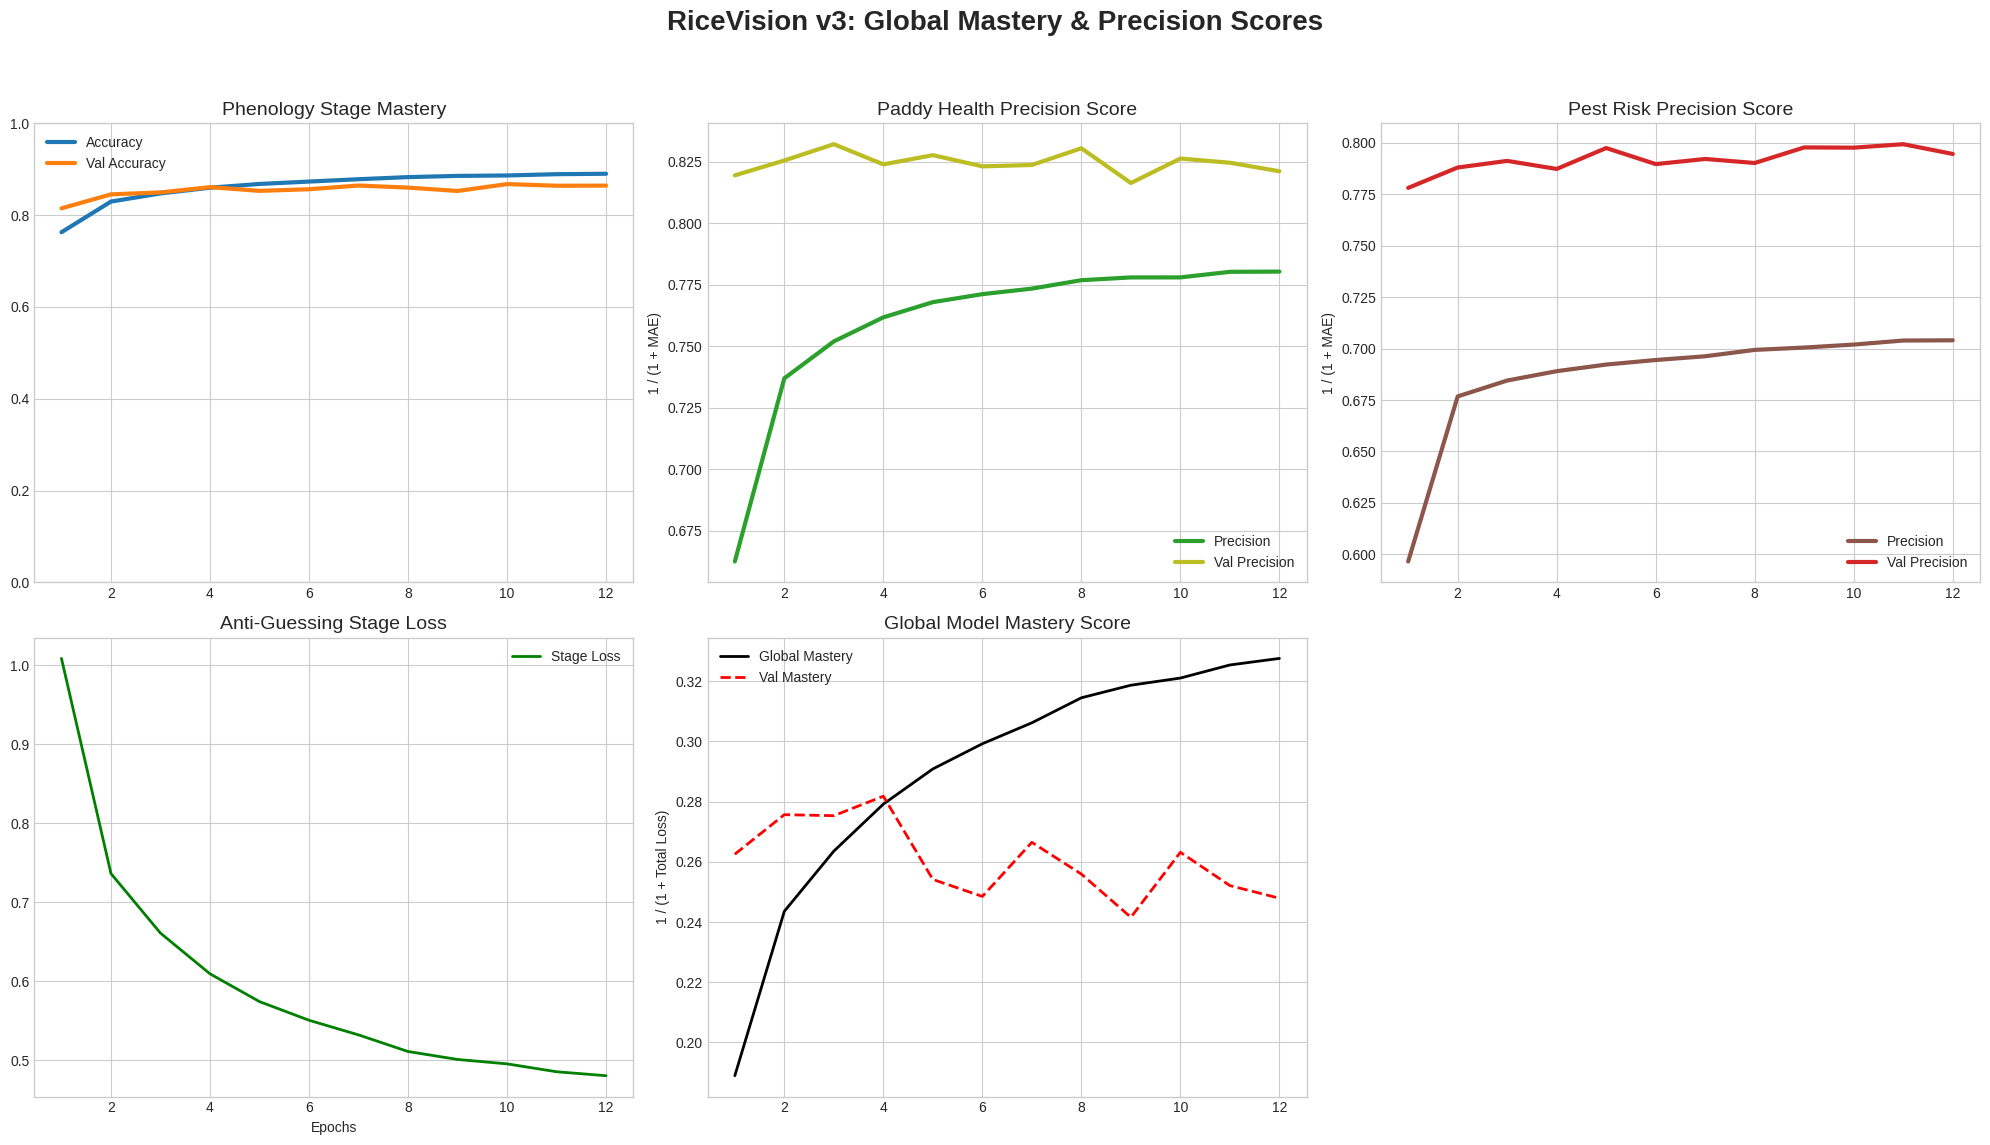

In [72]:
import numpy as np

def plot_accuracy_mastery_v3(history):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('RiceVision v3: Global Mastery & Precision Scores', fontsize=20, fontweight='bold')
    axes = axes.flatten()
    h = history.history
    epochs = range(1, len(h['loss']) + 1)

    # 1. Phenology Stage Precision
    axes[0].plot(epochs, h['stage_out_accuracy'], label='Accuracy', color='#1f77b4', linewidth=3)
    axes[0].plot(epochs, h['val_stage_out_accuracy'], label='Val Accuracy', color='#ff7f0e', linewidth=3)
    axes[0].set_title('Phenology Stage Mastery', fontsize=14)
    axes[0].set_ylim(0, 1)
    axes[0].legend()

    # 3. Paddy Health Precision (Inverted MAE)
    h_train = 1 / (1 + np.array(h['health_out_mae']))
    h_val = 1 / (1 + np.array(h['val_health_out_mae']))
    axes[1].plot(epochs, h_train, label='Precision', color='#2ca02c', linewidth=3)
    axes[1].plot(epochs, h_val, label='Val Precision', color='#bcbd22', linewidth=3)
    axes[1].set_title('Paddy Health Precision Score', fontsize=14)
    axes[1].set_ylabel('1 / (1 + MAE)')
    axes[1].legend()

    # 4. Pest Risk Precision (Inverted MAE)
    p_train = 1 / (1 + np.array(h['pest_out_mae']))
    p_val = 1 / (1 + np.array(h['val_pest_out_mae']))
    axes[2].plot(epochs, p_train, label='Precision', color='#8c564b', linewidth=3)
    axes[2].plot(epochs, p_val, label='Val Precision', color='#d62728', linewidth=3)
    axes[2].set_title('Pest Risk Precision Score', fontsize=14)
    axes[2].set_ylabel('1 / (1 + MAE)')
    axes[2].legend()

    # 5. Individual Stage Loss
    if 'stage_out_loss' in h:
        axes[3].plot(epochs, h['stage_out_loss'], label='Stage Loss', color='green', linewidth=2)
        axes[3].set_title('Anti-Guessing Stage Loss', fontsize=14)
        axes[3].set_xlabel('Epochs')
        axes[3].legend()

    # 6. Global Model Mastery (Inverted Total Loss)
    l_train = 1 / (1 + np.array(h['loss']))
    l_val = 1 / (1 + np.array(h['val_loss']))
    axes[4].plot(epochs, l_train, label='Global Mastery', color='black', linewidth=2)
    axes[4].plot(epochs, l_val, label='Val Mastery', color='red', linestyle='--', linewidth=2)
    axes[4].set_title('Global Model Mastery Score', fontsize=14)
    axes[4].set_ylabel('1 / (1 + Total Loss)')
    axes[4].legend()
    
    axes[5].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('model_mastery_summary.png', dpi=300)
    plt.show()
plot_accuracy_mastery_v3(history)

In [73]:
# 1. Update the dictionary with the EXACT names Keras is looking for
custom_objects = {
    'weighted_stage_ce_v2': weighted_stage_ce_v2, # Key must match the function name
    'robust_huber_loss': robust_huber_loss,
    'regression_accuracy': regression_accuracy
}

# 2. Load the model again
best_model = tf.keras.models.load_model(
    MODEL_NAME, 
    custom_objects=custom_objects
)

print("✅ Model loaded successfully!")

# 3. Evaluate
results = best_model.evaluate(test_ds_tuple, return_dict=True)

print(f"\n--- FINAL TEST SCORECARD ---")
print(f"Stage Accuracy:   {results['stage_out_accuracy']:.2%}")
print(f"Health Accuracy: {results['health_out_regression_accuracy']:.2%}") # NEW
print(f"Health MAE:      {results['health_out_mae']:.4f}")
print(f"Pest MAE:        {results['pest_out_mae']:.4f}")

✅ Model loaded successfully!
896/896 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - health_out_loss: 0.0156 - health_out_mae: 0.2177 - health_out_regression_accuracy: 0.9384 - loss: 2.9242 - pest_out_loss: 0.0257 - pest_out_mae: 0.2658 - pest_out_regression_accuracy: 0.8615 - stage_out_accuracy: 0.8634 - stage_out_loss: 0.7110

--- FINAL TEST SCORECARD ---
Stage Accuracy:   86.76%
Health Accuracy: 94.61%
Health MAE:      0.2102
Pest MAE:        0.2537


In [74]:
try:
    results = best_model.evaluate(test_ds_tuple, return_dict=True)
    
    print(f"\n{'='*40}")
    print(f"       TEST DATA PERFORMANCE")
    print(f"{'='*40}")
    # Use generic keys if the specific names were lost during SavedModel conversion
    for key, value in results.items():
        print(f"{key}: {value:.4f}")
except Exception as e:
    print(f"Evaluation failed: {e}")
    print("Try running a single prediction to verify the model works:")
    sample_x, _, _ = next(iter(test_ds_tuple))
    out = best_model(sample_x)
    print("Prediction keys found:", out.keys())

896/896 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - health_out_loss: 0.0156 - health_out_mae: 0.2177 - health_out_regression_accuracy: 0.9384 - loss: 2.9242 - pest_out_loss: 0.0257 - pest_out_mae: 0.2658 - pest_out_regression_accuracy: 0.8615 - stage_out_accuracy: 0.8634 - stage_out_loss: 0.7110

       TEST DATA PERFORMANCE
health_out_loss: 0.0158
health_out_mae: 0.2102
health_out_regression_accuracy: 0.9461
loss: 2.8000
pest_out_loss: 0.0257
pest_out_mae: 0.2537
pest_out_regression_accuracy: 0.8750
stage_out_accuracy: 0.8676
stage_out_loss: 0.6798


# **Stages**

🚀 Step 1: Generating all predictions at once...
896/896 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step
📦 Step 2: Extracting true labels...
📊 Generating Heatmap...


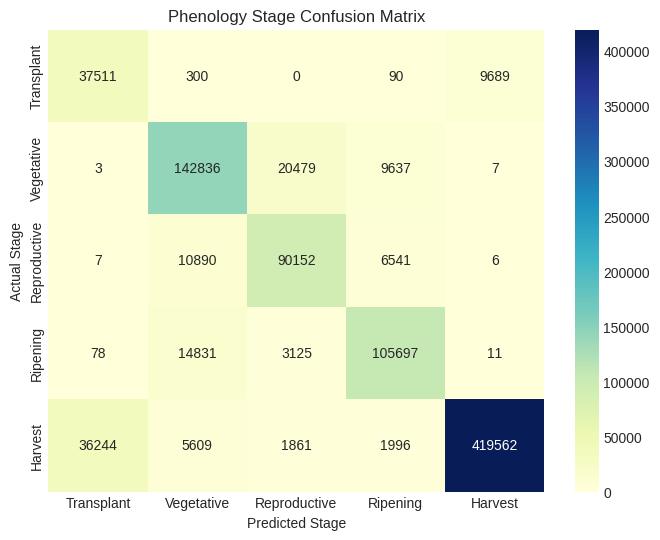


📈 Health MAE: 0.2102
📉 Pest MAE:   0.2537


In [75]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Define the names exactly as they appear in your dataset logic
stages = ['Transplant', 'Vegetative', 'Reproductive', 'Ripening', 'Harvest']

# 2. Optimized Label Extraction Fix
# In your code, y_dis_true needs to be integer type for the classification_report
def evaluate_fast_fixed(model, dataset, stage_names):
    print("🚀 Step 1: Generating all predictions at once...")
    all_preds = model.predict(dataset, verbose=1)
    
    y_stage_pred = np.argmax(all_preds[0], axis=-1)
    y_health_pred = all_preds[1].flatten()
    y_pest_pred = all_preds[2].flatten()

    print("📦 Step 2: Extracting true labels...")
    # More memory-efficient way to unpack the dataset
    y_true_list = [y for _, y, _ in dataset]
    
    y_stage_true = np.concatenate([y[0].numpy() for y in y_true_list]).flatten().astype(int)
    y_health_true = np.concatenate([y[1].numpy() for y in y_true_list]).flatten()
    y_pest_true = np.concatenate([y[2].numpy() for y in y_true_list]).flatten()

    # --- A. STAGE HEATMAP ---
    print("📊 Generating Heatmap...")
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_stage_true, y_stage_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
                xticklabels=stage_names, yticklabels=stage_names)
    plt.title("Phenology Stage Confusion Matrix")
    plt.ylabel('Actual Stage')
    plt.xlabel('Predicted Stage')
    plt.show()

    # --- C. REGRESSION ACCURACY ---
    # We only care about accuracy where weights were > 0 (growing season)
    # However, for a quick check:
    h_mae = np.mean(np.abs(y_health_true - y_health_pred))
    p_mae = np.mean(np.abs(y_pest_true - y_pest_pred))
    print(f"\n📈 Health MAE: {h_mae:.4f}")
    print(f"📉 Pest MAE:   {p_mae:.4f}")

# Run it!
evaluate_fast_fixed(best_model, test_ds_tuple, stages)

🚀 Step 1: Generating all predictions...
896/896 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step
📦 Step 2: Extracting true labels...

📊 Evaluating Stage Head (Classification Matrix)...


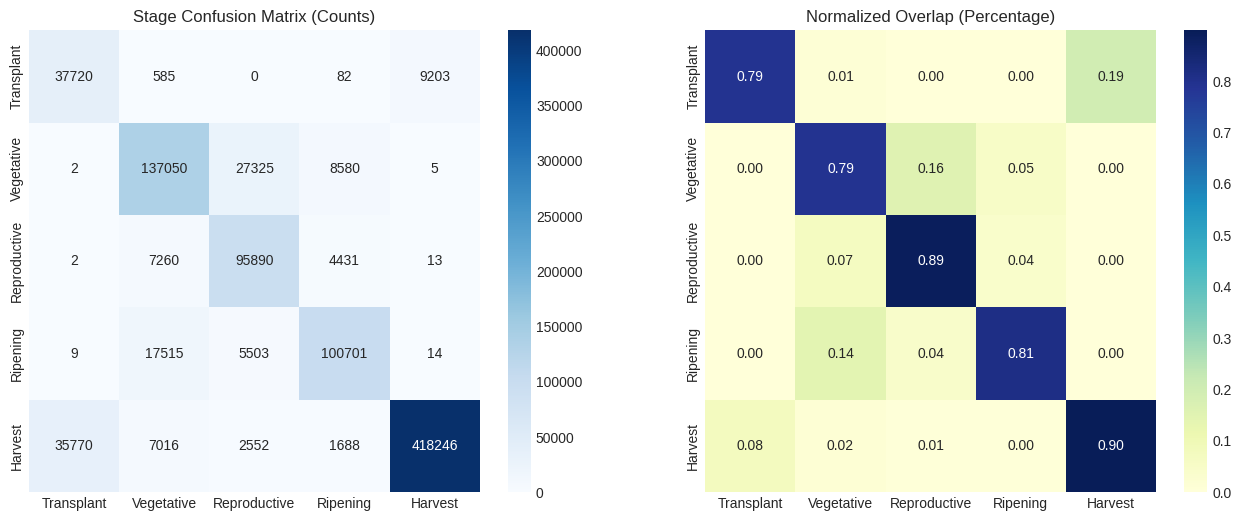


Detailed Phenology Report:
              precision    recall  f1-score   support

  Transplant       0.51      0.79      0.62     47590
  Vegetative       0.81      0.79      0.80    172962
Reproductive       0.73      0.89      0.80    107596
    Ripening       0.87      0.81      0.84    123742
     Harvest       0.98      0.90      0.94    465272

    accuracy                           0.86    917162
   macro avg       0.78      0.84      0.80    917162
weighted avg       0.88      0.86      0.87    917162


📈 Evaluating Health Head (Regression Stability)...


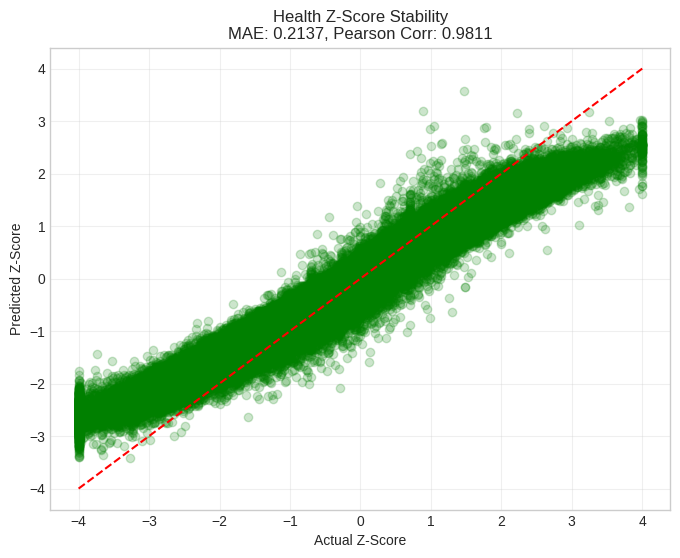


🦟 Evaluating Pest Head (Detection Precision)...


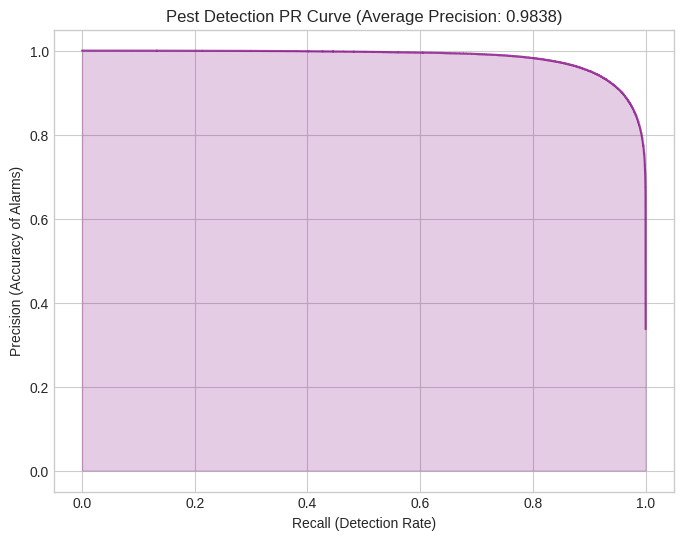

In [76]:
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error, r2_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

def evaluate_rice_vision_v7(model, dataset, stage_names):
    print("🚀 Step 1: Generating all predictions...")
    all_preds = model.predict(dataset, verbose=1)
    
    # Unpack predictions
    y_stage_pred_probs = all_preds[0]
    y_stage_pred = np.argmax(y_stage_pred_probs, axis=-1)
    y_health_pred = all_preds[1].flatten()
    y_pest_pred = all_preds[2].flatten()

    print("📦 Step 2: Extracting true labels...")
    y_true_list = [y for _, y, _ in dataset]
    y_stage_true = np.concatenate([y[0].numpy() for y in y_true_list]).flatten().astype(int)
    y_health_true = np.concatenate([y[1].numpy() for y in y_true_list]).flatten()
    y_pest_true = np.concatenate([y[2].numpy() for y in y_true_list]).flatten()

    # --- 1. STAGE HEAD EVALUATION (Classification) ---
    print("\n📊 Evaluating Stage Head (Classification Matrix)...")
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    
    # Raw Counts
    cm = confusion_matrix(y_stage_true, y_stage_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=stage_names, yticklabels=stage_names, ax=ax[0])
    ax[0].set_title("Stage Confusion Matrix (Counts)")
    
    # Normalized (to see % overlap between Repro/Veg)
    cm_norm = confusion_matrix(y_stage_true, y_stage_pred, normalize='true')
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlGnBu', xticklabels=stage_names, yticklabels=stage_names, ax=ax[1])
    ax[1].set_title("Normalized Overlap (Percentage)")
    plt.show()

    print("\nDetailed Phenology Report:")
    print(classification_report(y_stage_true, y_stage_pred, target_names=stage_names))

    # --- 2. HEALTH HEAD EVALUATION (Regression Stability) ---
    print("\n📈 Evaluating Health Head (Regression Stability)...")
    mae_h = mean_absolute_error(y_health_true, y_health_pred)
    corr_h, _ = pearsonr(y_health_true, y_health_pred)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(y_health_true, y_health_pred, alpha=0.2, color='green')
    plt.plot([y_health_true.min(), y_health_true.max()], [y_health_true.min(), y_health_true.max()], 'r--')
    plt.title(f"Health Z-Score Stability\nMAE: {mae_h:.4f}, Pearson Corr: {corr_h:.4f}")
    plt.xlabel("Actual Z-Score")
    plt.ylabel("Predicted Z-Score")
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- 3. PEST HEAD EVALUATION (Anomaly/Sparse Detection) ---
    print("\n🦟 Evaluating Pest Head (Detection Precision)...")
    # If Pest is sparse, PR Curve is better than a standard matrix
    precision, recall, _ = precision_recall_curve((y_pest_true > 0.5).astype(int), y_pest_pred)
    ap_score = average_precision_score((y_pest_true > 0.5).astype(int), y_pest_pred)

    plt.figure(figsize=(8, 6))
    plt.step(recall, precision, color='purple', alpha=0.7, where='post')
    plt.fill_between(recall, precision, alpha=0.2, color='purple')
    plt.xlabel('Recall (Detection Rate)')
    plt.ylabel('Precision (Accuracy of Alarms)')
    plt.title(f'Pest Detection PR Curve (Average Precision: {ap_score:.4f})')
    plt.show()

# Run the evaluation
evaluate_rice_vision_v7(model, test_ds_tuple, stages)

# **Health and pest**

🚀 Step 1: Extracting predictions and weights...
896/896 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step

REGRESSION PERFORMANCE (GROWING SEASON ONLY)
    Metric  Health (NDVI Z)  Pest (CPI)
       MAE         0.201347    0.228872
      RMSE         0.258191    0.307079
  R² Score         0.930794    0.946675
Acc (±0.5)         0.954707    0.904502

--- FIRST 10 SAMPLES (GROWING) ---
   Health_Actual  Health_Pred  Pest_Actual  Pest_Pred
0          0.717        0.423        0.909      0.647
1          0.837        0.547       -1.228     -1.638
2         -0.452       -0.115        0.000     -0.238
3          0.241       -0.077        0.234      0.120
4          0.908        0.680        1.497      1.334
5          0.327        0.214        0.599      1.291
6          0.746        0.508       -1.280     -0.958
7          0.707        0.638       -2.400     -1.670
8          0.929        0.523        0.192      0.152
9         -0.350       -0.143       -1.524     -1.237


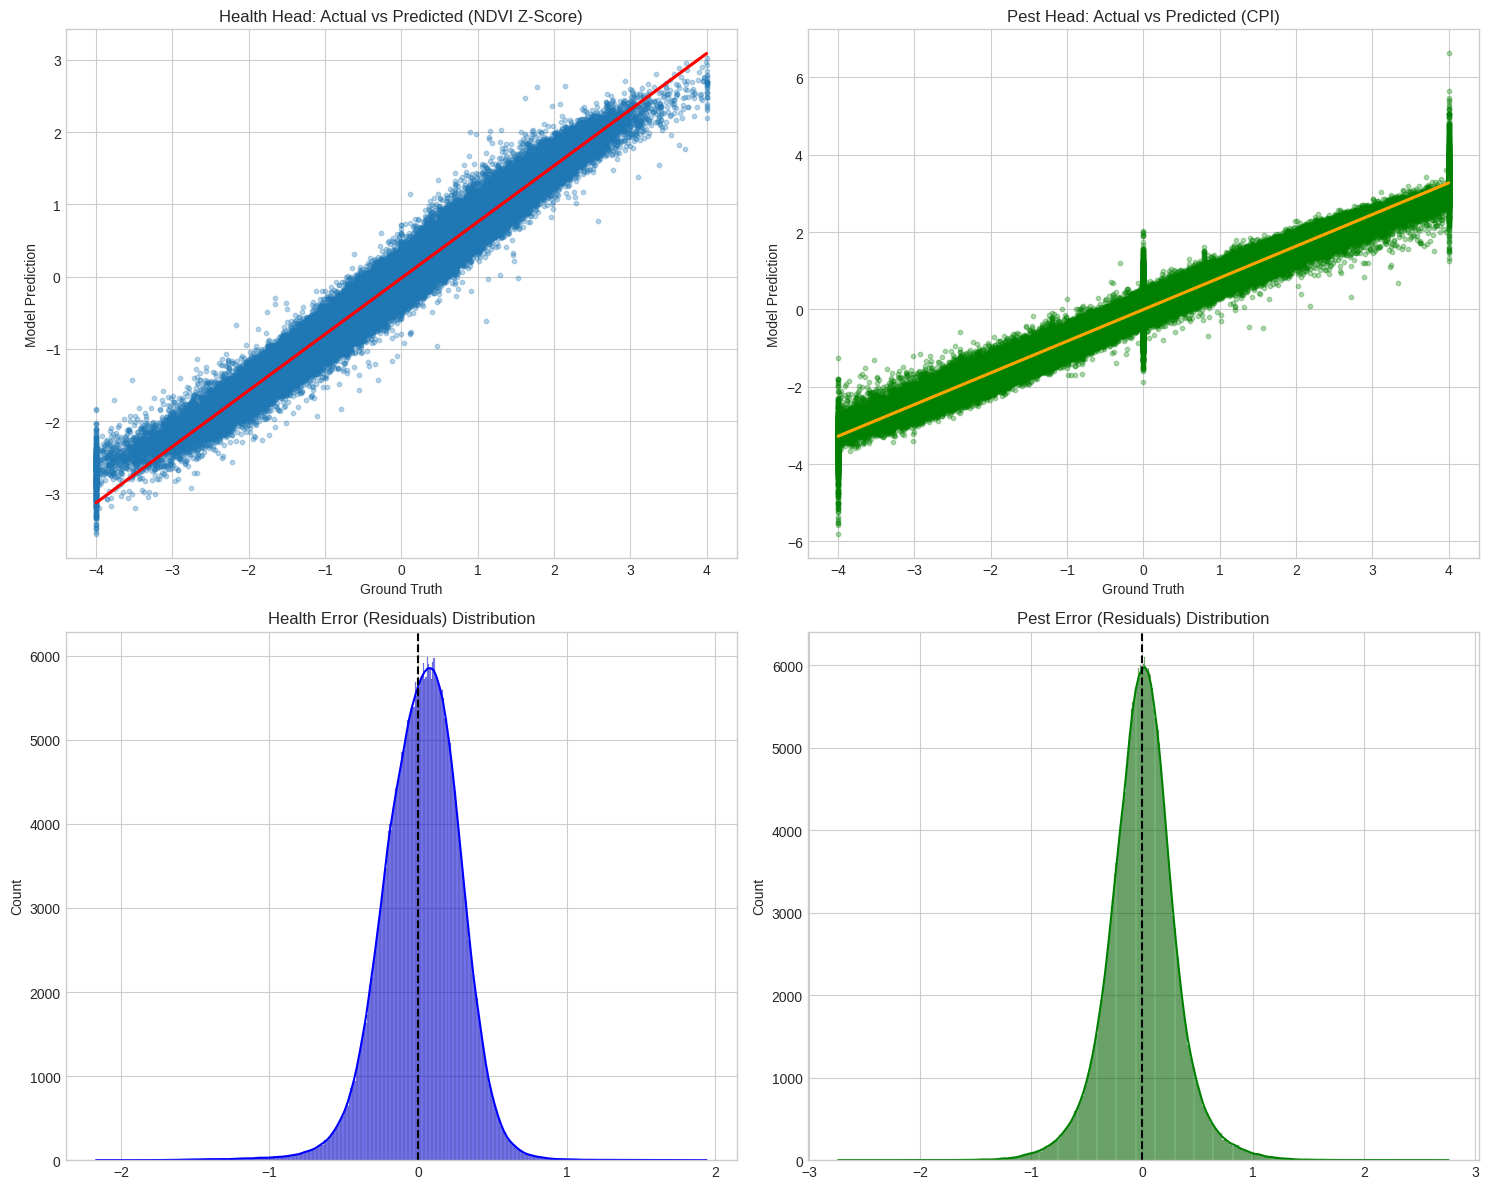

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_regression_heads(model, dataset):
    print("🚀 Step 1: Extracting predictions and weights...")
    # 1. Get raw model predictions
    all_preds = model.predict(dataset, verbose=1)
    
    # Indices based on model output order: [stage, health, pest, disaster]
    health_pred_raw = all_preds[1].flatten()
    pest_pred_raw = all_preds[2].flatten()

    # 2. Extract true labels and weights from the dataset
    y_true_list = []
    w_list = []
    for _, y_batch, w_batch in dataset:
        y_true_list.append(y_batch)
        w_list.append(w_batch)

    # Health (Index 1) and Pest (Index 2)
    health_true_raw = np.concatenate([y[1].numpy() for y in y_true_list]).flatten()
    pest_true_raw = np.concatenate([y[2].numpy() for y in y_true_list]).flatten()
    
    # Regression Weights (Gating)
    # Both heads use the same 'reg_weight', so we take index 1 or 2
    weights = np.concatenate([w[1].numpy() for w in w_list]).flatten()

    # 3. FILTER: Only keep samples where the crop was actually growing
    mask = weights > 0
    h_true, h_pred = health_true_raw[mask], health_pred_raw[mask]
    p_true, p_pred = pest_true_raw[mask], pest_pred_raw[mask]

    # --- A. METRICS TABLE ---
    stats = {
        "Metric": ["MAE", "RMSE", "R² Score", "Acc (±0.5)"],
        "Health (NDVI Z)": [
            mean_absolute_error(h_true, h_pred),
            np.sqrt(mean_squared_error(h_true, h_pred)),
            r2_score(h_true, h_pred),
            np.mean(np.abs(h_true - h_pred) < 0.5)
        ],
        "Pest (CPI)": [
            mean_absolute_error(p_true, p_pred),
            np.sqrt(mean_squared_error(p_true, p_pred)),
            r2_score(p_true, p_pred),
            np.mean(np.abs(p_true - p_pred) < 0.5)
        ]
    }
    print("\n" + "="*45 + "\nREGRESSION PERFORMANCE (GROWING SEASON ONLY)\n" + "="*45)
    print(pd.DataFrame(stats).to_string(index=False))

    # --- B. PREDICTION SAMPLE ---
    sample_df = pd.DataFrame({
        'Health_Actual': h_true[:10],
        'Health_Pred': h_pred[:10],
        'Pest_Actual': p_true[:10],
        'Pest_Pred': p_pred[:10]
    })
    print("\n--- FIRST 10 SAMPLES (GROWING) ---")
    print(sample_df.round(3))

    # --- C. VISUALIZATION ---
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Health: Actual vs Predicted
    sns.regplot(x=h_true, y=h_pred, ax=axes[0,0], scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
    axes[0,0].set_title("Health Head: Actual vs Predicted (NDVI Z-Score)")
    axes[0,0].set_xlabel("Ground Truth")
    axes[0,0].set_ylabel("Model Prediction")

    # 2. Pest: Actual vs Predicted
    sns.regplot(x=p_true, y=p_pred, ax=axes[0,1], scatter_kws={'alpha':0.3, 's':10, 'color':'green'}, line_kws={'color':'orange'})
    axes[0,1].set_title("Pest Head: Actual vs Predicted (CPI)")
    axes[0,1].set_xlabel("Ground Truth")
    axes[0,1].set_ylabel("Model Prediction")

    # 3. Health: Error Distribution
    sns.histplot(h_true - h_pred, kde=True, ax=axes[1,0], color='blue')
    axes[1,0].set_title("Health Error (Residuals) Distribution")
    axes[1,0].axvline(0, color='black', linestyle='--')

    # 4. Pest: Error Distribution
    sns.histplot(p_true - p_pred, kde=True, ax=axes[1,1], color='green')
    axes[1,1].set_title("Pest Error (Residuals) Distribution")
    axes[1,1].axvline(0, color='black', linestyle='--')

    plt.tight_layout()
    plt.show()

# Run the evaluation
evaluate_regression_heads(best_model, test_ds_tuple)

In [78]:
# Evaluate on validation or test set
results = best_model.evaluate(test_ds_tuple, return_dict=True)

print("\n--- RAW LOSS MAGNITUDES ---")
stage_loss = results["stage_out_loss"]
health_loss = results["health_out_loss"]
pest_loss = results["pest_out_loss"]

print(f"Stage Loss  : {stage_loss:.6f}")
print(f"Health Loss : {health_loss:.6f}")
print(f"Pest Loss   : {pest_loss:.6f}")

896/896 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - health_out_loss: 0.0156 - health_out_mae: 0.2177 - health_out_regression_accuracy: 0.9384 - loss: 2.9242 - pest_out_loss: 0.0257 - pest_out_mae: 0.2658 - pest_out_regression_accuracy: 0.8615 - stage_out_accuracy: 0.8634 - stage_out_loss: 0.7110

--- RAW LOSS MAGNITUDES ---
Stage Loss  : 0.679794
Health Loss : 0.015801
Pest Loss   : 0.025694


In [79]:
# Avoid division by zero
eps = 1e-8

target = stage_loss  # Make others match stage scale

new_health_weight = target / (health_loss + eps)
new_pest_weight   = target / (pest_loss + eps)

print("\n--- SUGGESTED BALANCED LOSS WEIGHTS ---")
print(f"Stage Weight  : 1.0")
print(f"Health Weight : {new_health_weight:.2f}")
print(f"Pest Weight   : {new_pest_weight:.2f}")


--- SUGGESTED BALANCED LOSS WEIGHTS ---
Stage Weight  : 1.0
Health Weight : 43.02
Pest Weight   : 26.46
